# Comparing Classifiers on a Bank Telemarketing Campaign

**Practical Application 17.1** — k-Nearest Neighbors vs. Logistic Regression vs. Decision Trees vs. Support Vector Machines

*Dataset: UCI Machine Learning Repository — Bank Marketing (Moro, Cortez & Rita, 2014)*

---

## 1. Business Understanding

A Portuguese retail bank sells **term deposits** by telephone. Between May 2008 and November 2010 it ran
17 outbound campaigns; this dataset records **41,188 individual calls**, each labelled with whether the
client ultimately subscribed to the deposit.

Outbound calling is expensive and the yield is low: only about **11 in every 100 calls** ends in a
subscription. Agent time is the binding constraint — the bank cannot call everyone, and every minute
spent on a client who will say "no" is a minute not spent on one who would have said "yes."

### The business question

> **Given what the bank knows about a client *before* the phone rings, how likely is that client to
> subscribe — and can we use that likelihood to decide who to call first?**

This is a **binary classification** problem, but the deliverable the business actually needs is a
**ranked call list**, not a yes/no verdict. That distinction drives every modelling choice below,
especially the evaluation metric (Section 6).

### What success looks like

| Business goal | Data-science translation | How we measure it |
|---|---|---|
| Reach the same number of subscribers with fewer calls | Rank clients by predicted probability | ROC-AUC, cumulative-gains / lift |
| Don't systematically miss likely subscribers | Keep recall high on the rare positive class | Recall, PR-AUC |
| Give the campaign team reasons, not just scores | Interpretable drivers | Logistic-regression odds ratios, permutation importance |

### Scope and honesty about causation

Everything below is **observational**. The bank did not randomise who it called, so a feature that
*predicts* subscription is not thereby a *cause* of it. Findings are phrased as targeting guidance —
who to call — rather than as levers guaranteed to change behaviour if manipulated.

## 2. Setup and Data Understanding

### 2.1 Imports and environment

In [1]:
# Standard scientific stack. Aliases follow the conventional short forms.
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Scikit-learn: preprocessing, model selection, the four classifiers, and metrics.
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")          # keep the notebook output readable
RANDOM_STATE = 42                          # one seed, reused everywhere, for reproducibility

# Consistent visual identity for every figure in the notebook.
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"no": "#94a3b8", "yes": "#0f766e"}
ACCENT, MUTED = "#0f766e", "#94a3b8"
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 12})

IMAGES = Path("../images")
IMAGES.mkdir(exist_ok=True)

def save_figure(fig, name):
    """Persist a figure to images/ so the README can embed it."""
    fig.savefig(IMAGES / f"{name}.png", dpi=110, bbox_inches="tight")

print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

pandas 3.0.2 | numpy 2.4.4 | seaborn 0.13.2


### 2.2 Loading the data

The file is the `bank-additional-full.csv` variant: all 41,188 records with the 20 input features,
including the five macroeconomic indicators added in the 2014 revision of the dataset. It is
semicolon-delimited.

In [2]:
bank = pd.read_csv("../data/bank-additional-full.csv", sep=";")

print(f"Rows: {bank.shape[0]:,}   Columns: {bank.shape[1]}")
print(f"Missing values (NaN): {bank.isna().sum().sum()}")
print(f"Exact duplicate rows:  {bank.duplicated().sum()}")
bank.head()

Rows: 41,188   Columns: 21
Missing values (NaN): 0
Exact duplicate rows:  12


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 2.3 The feature dictionary

The 20 inputs fall into four natural groups. Keeping these groups straight matters, because
one of them turns out to be unusable for prediction (Section 4.2).

In [3]:
# Group the columns by what the bank actually knows, and when it knows it.
FEATURE_GROUPS = {
    "Client demographics": ["age", "job", "marital", "education"],
    "Client banking history": ["default", "housing", "loan"],
    "Current campaign contact": ["contact", "month", "day_of_week", "duration", "campaign"],
    "Previous campaign history": ["pdays", "previous", "poutcome"],
    "Macroeconomic context": ["emp.var.rate", "cons.price.idx", "cons.conf.idx",
                              "euribor3m", "nr.employed"],
}

dictionary = pd.DataFrame(
    [(group, col, str(bank[col].dtype), bank[col].nunique())
     for group, cols in FEATURE_GROUPS.items() for col in cols],
    columns=["Group", "Feature", "Dtype", "Distinct values"],
)
dictionary

,Group,Feature,Dtype,Distinct values
0,Client demographics,age,int64,78
1,Client demographics,job,str,12
2,Client demographics,marital,str,4
3,Client demographics,education,str,8
4,Client banking history,default,str,3
5,Client banking history,housing,str,3
6,Client banking history,loan,str,3
7,Current campaign contact,contact,str,2
8,Current campaign contact,month,str,10
9,Current campaign contact,day_of_week,str,5


### 2.4 The target: a heavily imbalanced outcome

This is the single most consequential fact about the dataset, and it constrains both the choice of
metric and the way the models must be trained.

Subscription rate: 11.27%  (4,640 of 41,188 calls)
Majority-class ('always predict no') accuracy would be 88.73%


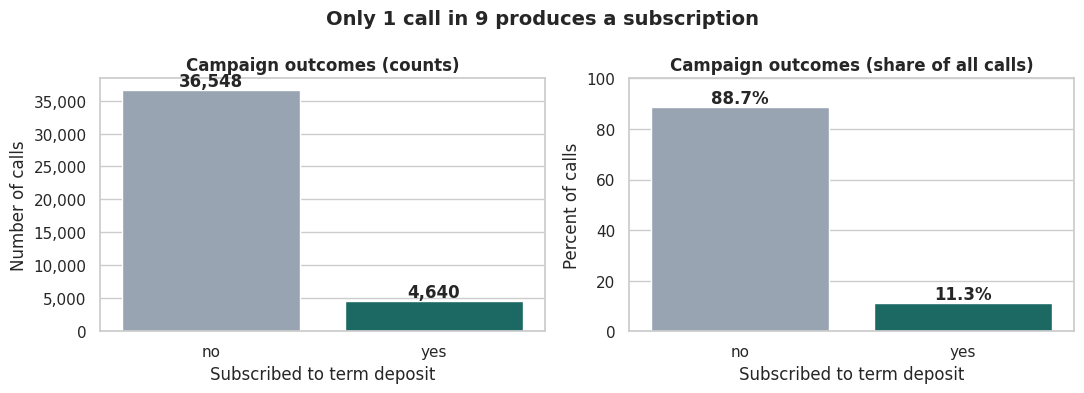

In [4]:
target_counts = bank["y"].value_counts()
target_share = bank["y"].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: raw counts, to show how few positives there are in absolute terms.
sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index,
            palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title("Campaign outcomes (counts)")
axes[0].set_xlabel("Subscribed to term deposit")
axes[0].set_ylabel("Number of calls")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")

# Right: the same thing as a share, which is the number that drives the metric choice.
sns.barplot(x=target_share.index, y=target_share.values * 100, hue=target_share.index,
            palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title("Campaign outcomes (share of all calls)")
axes[1].set_xlabel("Subscribed to term deposit")
axes[1].set_ylabel("Percent of calls")
axes[1].set_ylim(0, 100)
for i, v in enumerate(target_share.values * 100):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontweight="bold")

fig.suptitle("Only 1 call in 9 produces a subscription", fontsize=14, fontweight="bold")
fig.tight_layout()
save_figure(fig, "01_class_balance")
plt.show()

print(f"Subscription rate: {target_share['yes']:.2%}  ({target_counts['yes']:,} of {len(bank):,} calls)")
print(f"Majority-class ('always predict no') accuracy would be {target_share['no']:.2%}")

> **Read this carefully:** a model that predicts "no" for every single client is **88.7% accurate**
> and completely worthless. Accuracy is not a usable metric here, and Section 6 formalises what
> replaces it.

### 2.5 Descriptive statistics for the numeric features

In [5]:
numeric_cols = bank.select_dtypes(include=np.number).columns.tolist()

summary = bank[numeric_cols].describe().T
summary["skew"] = bank[numeric_cols].skew()
summary = summary[["count", "mean", "std", "min", "50%", "max", "skew"]]
summary.columns = ["Count", "Mean", "Std", "Min", "Median", "Max", "Skew"]
summary.round(2)

,Count,Mean,Std,Min,Median,Max,Skew
age,41188.0,40.02,10.42,17.00,38.00,98.00,0.78
duration,41188.0,258.29,259.28,0.00,180.00,4918.00,3.26
campaign,41188.0,2.57,2.77,1.00,2.00,56.00,4.76
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,-4.92
previous,41188.0,0.17,0.49,0.00,0.00,7.00,3.83
emp.var.rate,41188.0,0.08,1.57,-3.40,1.10,1.40,-0.72
cons.price.idx,41188.0,93.58,0.58,92.20,93.75,94.77,-0.23
cons.conf.idx,41188.0,-40.50,4.63,-50.80,-41.80,-26.90,0.30
euribor3m,41188.0,3.62,1.73,0.63,4.86,5.04,-0.71
nr.employed,41188.0,5167.04,72.25,4963.60,5191.00,5228.10,-1.04


Three things stand out and each one needs handling:

1. **`duration` is wildly skewed** (mean 258 s, max 4,918 s) — and, as Section 4.2 shows, it cannot
   legitimately be used at all.
2. **`pdays` has a median of 999**, which is not a number of days — it is the dataset's sentinel for
   *"this client was never contacted in a previous campaign."* Left as-is it would tell the models
   that most clients were last contacted nearly three years ago.
3. **`campaign` reaches 56 calls** to a single client in one campaign, a long right tail of
   heavily-worked contacts.

In [6]:
# The pdays sentinel, quantified — this is a data-cleaning issue, not a distribution.
never_contacted = (bank["pdays"] == 999).mean()
print(f"pdays == 999 (never previously contacted): {never_contacted:.2%} of rows")
print(f"Genuine pdays values range from {bank.loc[bank['pdays'] != 999, 'pdays'].min()} "
      f"to {bank.loc[bank['pdays'] != 999, 'pdays'].max()} days")
print()

# 'unknown' is a real, meaningful level in several categorical columns, not missing data.
unknown_counts = (bank == "unknown").sum()
unknown_counts = unknown_counts[unknown_counts > 0].sort_values(ascending=False)
unknown_table = pd.DataFrame({
    "'unknown' rows": unknown_counts,
    "Share": (unknown_counts / len(bank)).map("{:.1%}".format),
})
unknown_table

pdays == 999 (never previously contacted): 96.32% of rows
Genuine pdays values range from 0 to 27 days



,'unknown' rows,Share
default,8597,20.9%
education,1731,4.2%
housing,990,2.4%
loan,990,2.4%
job,330,0.8%
marital,80,0.2%


No cell in this dataset is empty, so `isna()` reports zero — but `unknown` is doing the work that
`NaN` normally does. It is kept as an explicit category rather than imputed, for two reasons: it is
genuinely informative (a client whose credit-default status the bank cannot establish is a
different kind of client), and imputing 21% of `default` would invent more information than it
recovers.

### 2.6 Distributions of the numeric features

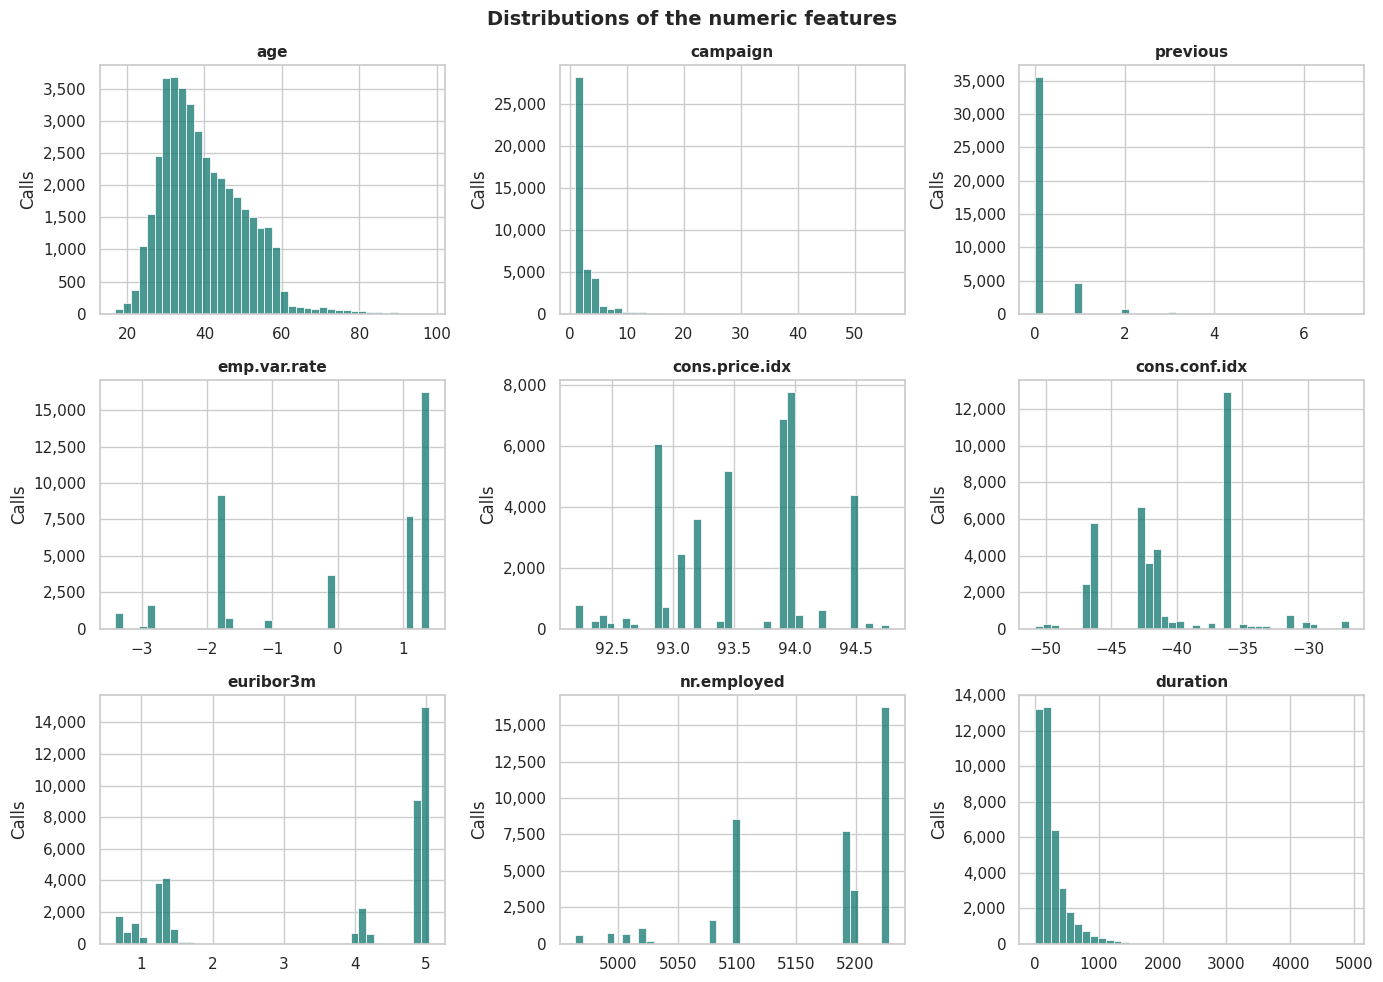

In [7]:
plot_cols = ["age", "campaign", "previous", "emp.var.rate",
             "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "duration"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.histplot(bank[col], bins=40, color=ACCENT, ax=ax)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Calls")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

fig.suptitle("Distributions of the numeric features", fontsize=14, fontweight="bold")
fig.tight_layout()
save_figure(fig, "02_numeric_distributions")
plt.show()

The five macroeconomic variables are visibly **multi-modal rather than bell-shaped**. That is not
noise: the campaigns ran across the 2008–2010 financial crisis, so each cluster is a distinct
economic regime, and every client contacted in the same month shares the same values. This matters
later for both multicollinearity and generalisation.

### 2.7 How the numeric features separate the two outcomes

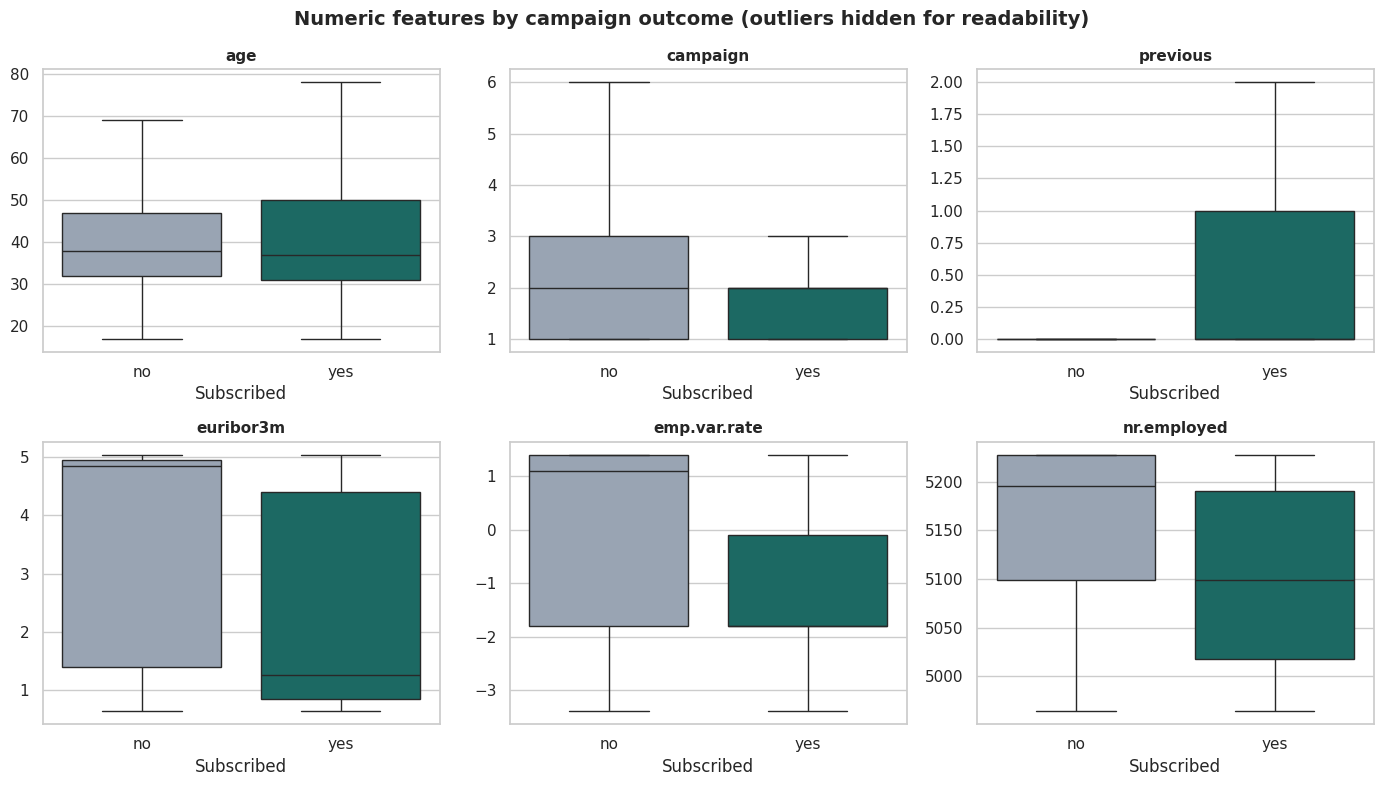

In [8]:
compare_cols = ["age", "campaign", "previous", "euribor3m", "emp.var.rate", "nr.employed"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), compare_cols):
    sns.boxplot(data=bank, x="y", y=col, hue="y", palette=PALETTE, legend=False,
                showfliers=False, ax=ax)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Subscribed")
    ax.set_ylabel("")

fig.suptitle("Numeric features by campaign outcome (outliers hidden for readability)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save_figure(fig, "03_numeric_by_outcome")
plt.show()

The economic indicators separate the classes far more sharply than the client's own attributes do.
Subscribers cluster in periods of **low interest rates and a contracting workforce** — when deposit
rates were relatively attractive and clients were looking for safety. Age barely moves; `campaign`
moves the wrong way (more calls, fewer subscriptions).

### 2.8 Conversion rates across the categorical features

For a targeting problem, the informative view is not "how many clients are in this category" but
"what share of them said yes." The dashed line marks the 11.3% overall base rate; bars are
annotated with the number of calls behind them, because a spectacular rate on 44 clients is not
a finding.

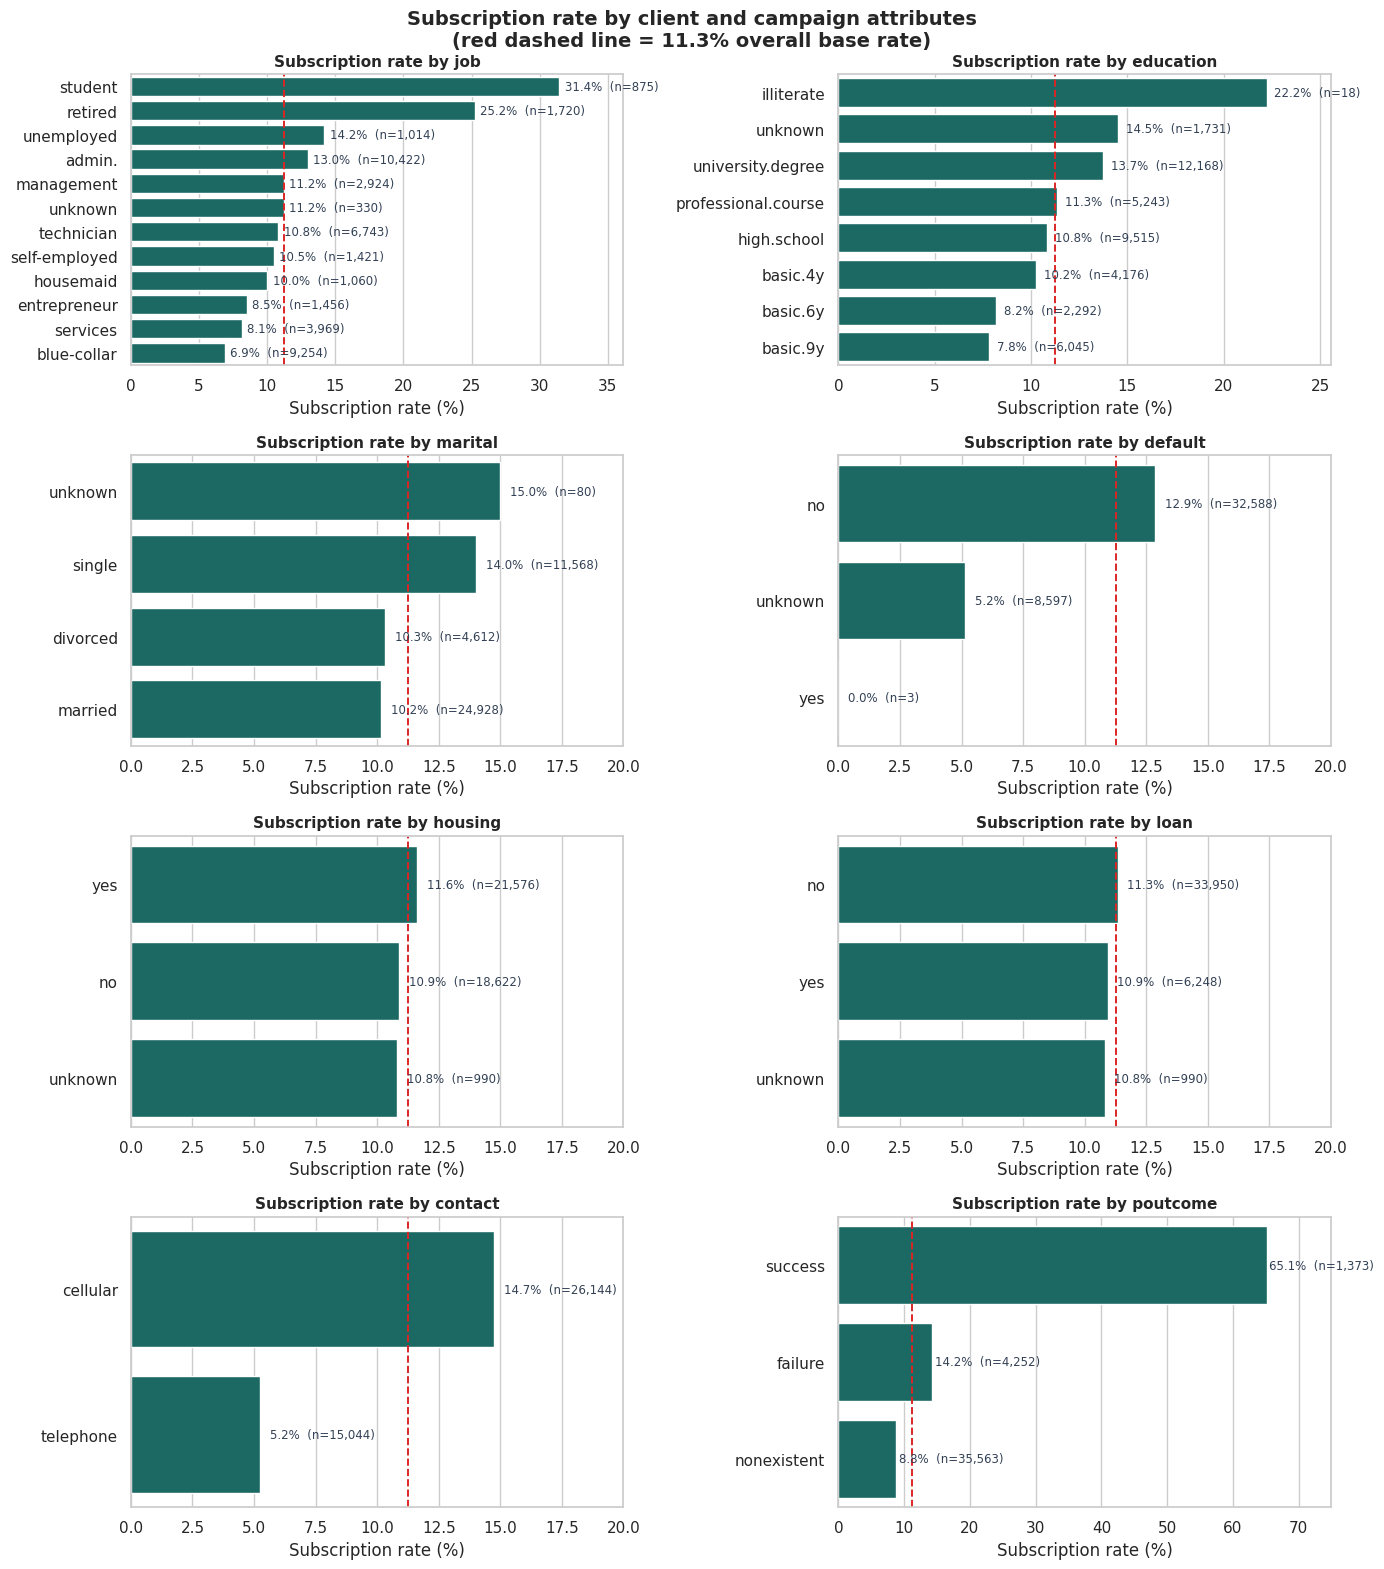

In [9]:
base_rate = (bank["y"] == "yes").mean()

def conversion_by(column, data=bank):
    """Subscription rate and volume for each level of a categorical column."""
    out = (data.groupby(column, observed=True)["y"]
               .agg(rate=lambda s: (s == "yes").mean(), calls="size")
               .sort_values("rate", ascending=False))
    return out

cat_to_plot = ["job", "education", "marital", "default",
               "housing", "loan", "contact", "poutcome"]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.ravel(), cat_to_plot):
    stats_tbl = conversion_by(col)
    sns.barplot(x=stats_tbl["rate"] * 100, y=stats_tbl.index, color=ACCENT, ax=ax)
    ax.axvline(base_rate * 100, color="#dc2626", linestyle="--", linewidth=1.4)
    ax.set_title(f"Subscription rate by {col}", fontsize=11)
    ax.set_xlabel("Subscription rate (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, max(stats_tbl["rate"].max() * 115, 20))
    # Annotate each bar with the number of calls it summarises.
    for i, (rate, calls) in enumerate(zip(stats_tbl["rate"], stats_tbl["calls"])):
        ax.text(rate * 100 + 0.4, i, f"{rate:.1%}  (n={calls:,})",
                va="center", fontsize=8.5, color="#334155")

fig.suptitle("Subscription rate by client and campaign attributes\n"
             "(red dashed line = 11.3% overall base rate)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save_figure(fig, "04_categorical_conversion")
plt.show()

Reading across the panels:

- **`poutcome` is the strongest single signal in the entire dataset.** Clients who accepted in a
  previous campaign convert at **65%** — nearly six times the base rate.
- **Students (31%) and retirees (25%)** convert two to three times better than average; **blue-collar
  workers (7%)** and **services staff (8%)** convert well below it.
- **`contact` matters a lot**: cellular contacts convert at 14.7% against 5.2% for landlines.
- **`default`** looks powerful, but only because `yes` has just 3 rows — the real signal is that
  `unknown` converts at half the base rate.
- **`housing` and `loan` are nearly flat.** They look like plausible predictors and are not.

### 2.9 Timing and the previous-campaign relationship

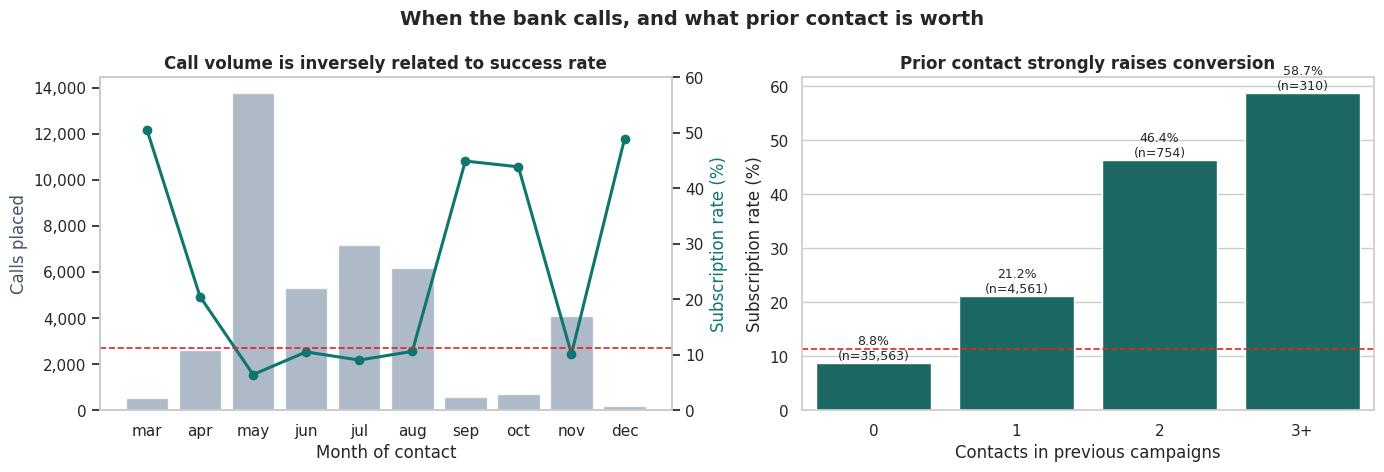

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# --- Left: month, ordered chronologically rather than by rate ---
month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
month_tbl = conversion_by("month").reindex(month_order)

ax1 = axes[0]
ax1.bar(month_order, month_tbl["calls"], color=MUTED, alpha=0.75, label="Calls placed")
ax1.set_ylabel("Calls placed", color="#475569")
ax1.set_xlabel("Month of contact")
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(month_order, month_tbl["rate"] * 100, color=ACCENT, marker="o", linewidth=2.2,
         label="Subscription rate")
ax2.axhline(base_rate * 100, color="#dc2626", linestyle="--", linewidth=1.2)
ax2.set_ylabel("Subscription rate (%)", color=ACCENT)
ax2.set_ylim(0, 60)
ax2.grid(False)
ax1.set_title("Call volume is inversely related to success rate")

# --- Right: number of prior contacts ---
prev_tbl = (bank.assign(previous_capped=bank["previous"].clip(upper=3))
                .groupby("previous_capped")["y"]
                .agg(rate=lambda s: (s == "yes").mean(), calls="size"))
labels = ["0", "1", "2", "3+"]

ax3 = axes[1]
sns.barplot(x=labels, y=prev_tbl["rate"] * 100, color=ACCENT, ax=ax3)
ax3.axhline(base_rate * 100, color="#dc2626", linestyle="--", linewidth=1.2)
ax3.set_title("Prior contact strongly raises conversion")
ax3.set_xlabel("Contacts in previous campaigns")
ax3.set_ylabel("Subscription rate (%)")
for i, (rate, calls) in enumerate(zip(prev_tbl["rate"], prev_tbl["calls"])):
    ax3.text(i, rate * 100 + 0.6, f"{rate:.1%}\n(n={calls:,})", ha="center", fontsize=9)

fig.suptitle("When the bank calls, and what prior contact is worth",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save_figure(fig, "05_timing_and_history")
plt.show()

The left panel is the most operationally interesting chart in the notebook. **May is the bank's
busiest month by a wide margin and its *worst* converting month (6.4%).** March, September, October
and December convert at 40–50% on tiny volumes. The bank is spending its capacity in exactly the
wrong months — though the caveat in Section 9 about *why* those months are low-volume matters before
anyone reallocates a call centre.

The right panel shows conversion roughly doubling with the first prior contact and doubling again
after that, which is why `poutcome`, `previous` and `pdays` are treated as a group in Section 4.

### 2.10 Correlation among the numeric features

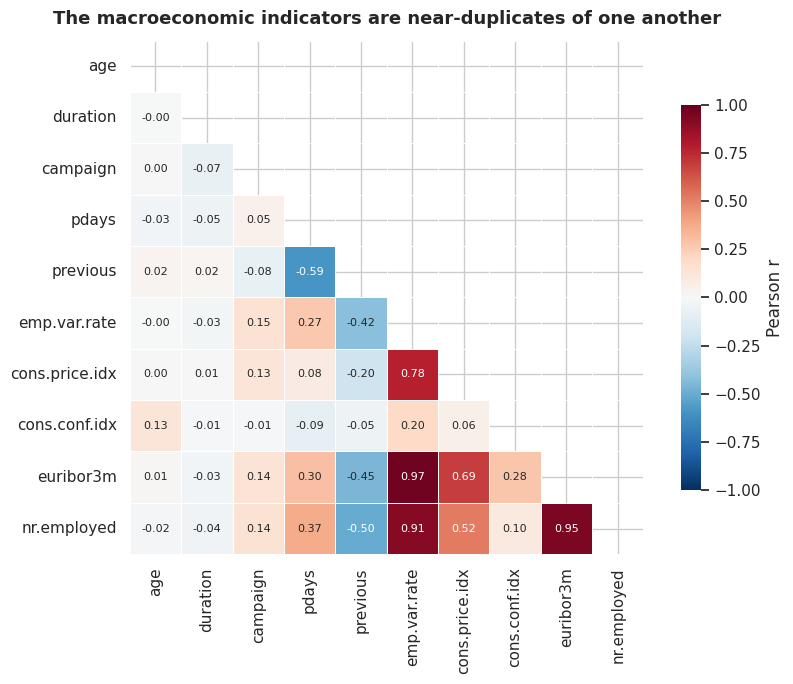

In [11]:
corr = bank[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))       # upper triangle is redundant
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.75, "label": "Pearson r"}, annot_kws={"size": 8}, ax=ax)
ax.set_title("The macroeconomic indicators are near-duplicates of one another",
             fontsize=13, pad=12)
fig.tight_layout()
save_figure(fig, "06_correlation_heatmap")
plt.show()

`euribor3m`, `emp.var.rate` and `nr.employed` are correlated at **r = 0.90 to 0.97**. They are three
measurements of the same underlying business cycle. This **multicollinearity** does not hurt
predictive accuracy, but it makes individual logistic-regression coefficients unstable and hard to
read — a caveat that returns in Section 8.1.

## 3. Inferential Statistics

The bar charts above show *differences*. Statistics tells us which of those differences are large
enough — given the sample sizes behind them — to act on. Two families of test are used:

- **Categorical features vs. the target:** a chi-square test of independence, reported alongside
  **Cramér's V**, an effect size bounded in [0, 1]. With 41,188 rows almost everything is
  "significant", so the p-value alone is close to useless; V is what separates a real driver from a
  detectable-but-trivial one.
- **Numeric features vs. the target:** the **Mann-Whitney U** test (the distributions are skewed and
  multi-modal, so a t-test's assumptions do not hold) with the **rank-biserial correlation** as the
  effect size.

In [12]:
def cramers_v(confusion):
    """Cramér's V: chi-square effect size for two categorical variables, bounded in [0, 1]."""
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()
    min_dim = min(confusion.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

categorical_cols = [c for c in bank.columns if c not in numeric_cols + ["y"]]

rows = []
for col in categorical_cols:
    table = pd.crosstab(bank[col], bank["y"])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    rows.append({
        "Feature": col,
        "Chi-square": chi2,
        "df": dof,
        "p-value": p,
        "Cramer's V": cramers_v(table),
    })

chi_square_results = (pd.DataFrame(rows)
                        .sort_values("Cramer's V", ascending=False)
                        .reset_index(drop=True))
chi_square_results.style.format({
    "Chi-square": "{:,.0f}", "p-value": "{:.3g}", "Cramer's V": "{:.3f}",
}).background_gradient(subset=["Cramer's V"], cmap="Greens")

,Feature,Chi-square,df,p-value,Cramer's V
0,poutcome,"4,231",2,0,0.320
1,month,"3,101",9,0,0.274
2,job,961,11,4.19e-199,0.153
3,contact,862,1,1.53e-189,0.145
4,default,407,2,5.16e-89,0.099
5,education,193,7,3.31e-38,0.068
6,marital,123,3,2.07e-26,0.055
7,day_of_week,26,4,2.96e-05,0.025
8,housing,6,2,0.0583,0.012
9,loan,1,2,0.579,0.005


Every categorical feature is statistically significant at any conventional threshold — which is
exactly the point about large samples. Ranked by **effect size**, though, a clear hierarchy appears:
`poutcome` (V = 0.32) and `month` (V = 0.27) are substantial; `job` and `contact` (V ≈ 0.15) are
moderate; and **`housing` (V = 0.012) and `loan` (V = 0.005) are effectively noise** despite
p-values that a careless reading would treat as meaningful. Two features a marketing team would
intuitively reach for — does the client have a mortgage, does the client have a personal loan —
carry essentially no information about whether they will buy a term deposit.

In [13]:
def rank_biserial(group_a, group_b):
    """Effect size for Mann-Whitney U: (2*U)/(n1*n2) - 1, in [-1, 1]."""
    u = stats.mannwhitneyu(group_a, group_b, alternative="two-sided").statistic
    return 2 * u / (len(group_a) * len(group_b)) - 1

subscribed = bank[bank["y"] == "yes"]
not_subscribed = bank[bank["y"] == "no"]

rows = []
for col in numeric_cols:
    a, b = subscribed[col], not_subscribed[col]
    u_stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    rows.append({
        "Feature": col,
        "Mean (subscribed)": a.mean(),
        "Mean (not subscribed)": b.mean(),
        "p-value": p,
        "Rank-biserial r": rank_biserial(a, b),
    })

numeric_tests = (pd.DataFrame(rows)
                   .assign(_abs=lambda d: d["Rank-biserial r"].abs())
                   .sort_values("_abs", ascending=False)
                   .drop(columns="_abs")
                   .reset_index(drop=True))
numeric_tests.style.format({
    "Mean (subscribed)": "{:,.2f}", "Mean (not subscribed)": "{:,.2f}",
    "p-value": "{:.3g}", "Rank-biserial r": "{:+.3f}",
}).background_gradient(subset=["Rank-biserial r"], cmap="RdBu_r", vmin=-1, vmax=1)

,Feature,Mean (subscribed),Mean (not subscribed),p-value,Rank-biserial r
0,duration,553.19,220.84,0,+0.637
1,nr.employed,"5,095.12","5,176.17",0,-0.498
2,euribor3m,2.12,3.81,0,-0.487
3,emp.var.rate,-1.23,0.25,0,-0.434
4,cons.price.idx,93.35,93.60,9.57e-136,-0.221
5,previous,0.49,0.13,0,+0.219
6,pdays,792.04,984.11,0,-0.193
7,campaign,2.05,2.63,3.42e-38,-0.110
8,cons.conf.idx,-39.79,-40.59,5.9e-17,+0.075
9,age,40.91,39.91,0.0161,-0.022


`duration` has by far the largest effect (r = +0.64) — the reason it must be removed anyway is
explained in Section 4.2. After it, the four strongest are **all macroeconomic**: `nr.employed`
(−0.50), `euribor3m` (−0.49), `emp.var.rate` (−0.43) and `cons.price.idx` (−0.22). The negative
signs say the same thing three times over: subscriptions rose when employment and interest rates
fell.

The client's own `age` is essentially uninformative on its own (r = −0.02) even though its p-value
is highly significant — the clearest illustration in the notebook of why effect size and
significance must be read together.

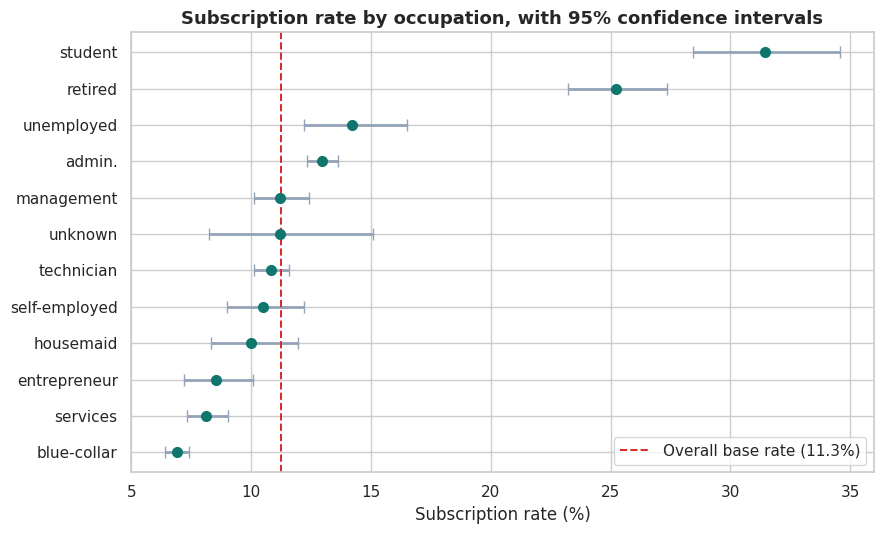

In [14]:
def wilson_interval(successes, trials, z=1.96):
    """Wilson score 95% confidence interval for a proportion - stable for small n and low rates."""
    if trials == 0:
        return (np.nan, np.nan)
    p_hat = successes / trials
    denom = 1 + z**2 / trials
    centre = (p_hat + z**2 / (2 * trials)) / denom
    half = z * np.sqrt(p_hat * (1 - p_hat) / trials + z**2 / (4 * trials**2)) / denom
    return (centre - half, centre + half)

# Confidence intervals make clear which occupational differences are real and which are small-sample noise.
job_stats = (bank.groupby("job")["y"]
                 .agg(successes=lambda s: (s == "yes").sum(), trials="size"))
job_stats["rate"] = job_stats["successes"] / job_stats["trials"]
job_stats[["lo", "hi"]] = job_stats.apply(
    lambda r: pd.Series(wilson_interval(r["successes"], r["trials"])), axis=1)
job_stats = job_stats.sort_values("rate")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(job_stats["rate"] * 100, job_stats.index,
            xerr=[(job_stats["rate"] - job_stats["lo"]) * 100,
                  (job_stats["hi"] - job_stats["rate"]) * 100],
            fmt="o", color=ACCENT, ecolor="#94a3b8", elinewidth=2, capsize=4, markersize=7)
ax.axvline(base_rate * 100, color="#dc2626", linestyle="--", linewidth=1.4,
           label=f"Overall base rate ({base_rate:.1%})")
ax.set_title("Subscription rate by occupation, with 95% confidence intervals", fontsize=13)
ax.set_xlabel("Subscription rate (%)")
ax.set_ylabel("")
ax.legend(loc="lower right", frameon=True)
fig.tight_layout()
save_figure(fig, "07_job_confidence_intervals")
plt.show()

The intervals separate cleanly for the extremes: students and retirees sit far above the base rate
and blue-collar workers far below, with no overlap. The middle of the pack — technicians,
management, self-employed, housemaids — has intervals that all straddle the base rate, meaning
those occupational labels carry no usable targeting signal on their own.

## 4. Data Preparation

### 4.1 Duplicate records

In [15]:
before = len(bank)
bank = bank.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(bank)} exact duplicate rows -> {len(bank):,} remain")

Removed 12 exact duplicate rows -> 41,176 remain


### 4.2 Dropping `duration` — the most important decision in this notebook

`duration` is the length of the call in seconds. It is the strongest predictor in the dataset by a
long way, and it is **unusable**. The UCI documentation is unambiguous:

> *"This attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the
> duration is not known before a call is performed... Thus, this input should only be included for
> benchmark purposes and should be discarded if the intention is to have a realistic predictive
> model."*

The problem is one of **timing, not correlation**. To know a call lasted 512 seconds, the call must
already have happened — so a model using `duration` cannot answer "who should we call?", which is
the entire business question. Worse, the causality runs backwards: clients say yes *and therefore*
stay on the phone.

Let's quantify what including it would buy, and then throw it away anyway.

In [16]:
# One shared cross-validation strategy, reused for every model in Section 7.
# shuffle=True matters here: the rows arrive in chronological order, and an unshuffled
# split would silently turn every fold into a forecasting task (see Section 9.2).
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# A quick like-for-like comparison: identical pipeline, only the duration column differs.
def quick_auc(frame):
    """Cross-validated ROC-AUC from a plain logistic regression on the given feature frame."""
    y_num = (bank["y"] == "yes").astype(int)
    cats = [c for c in frame.columns if frame[c].dtype == object or str(frame[c].dtype) == "str"]
    nums = [c for c in frame.columns if c not in cats]
    pipe = Pipeline([
        ("prep", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cats),
            ("num", StandardScaler(), nums),
        ])),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    return cross_val_score(pipe, frame, y_num, cv=CV, scoring="roc_auc", n_jobs=2).mean()

features_all = bank.drop(columns=["y"])
auc_with = quick_auc(features_all)
auc_without = quick_auc(features_all.drop(columns=["duration"]))

print(f"5-fold ROC-AUC WITH duration:    {auc_with:.4f}   <- unusable in production")
print(f"5-fold ROC-AUC WITHOUT duration: {auc_without:.4f}   <- honest, deployable")
print(f"Apparent 'cost' of doing this correctly: {auc_with - auc_without:.4f} AUC")

5-fold ROC-AUC WITH duration:    0.9349   <- unusable in production
5-fold ROC-AUC WITHOUT duration: 0.7914   <- honest, deployable
Apparent 'cost' of doing this correctly: 0.1435 AUC


Keeping `duration` would inflate AUC by roughly 0.14 — an impressive-looking number that describes a
model which can only score calls the bank has already made. **Every result from here on excludes it.**
This is the difference between a notebook that scores well and a model that works.

In [17]:
bank = bank.drop(columns=["duration"])
print(f"Feature space after dropping duration: {bank.shape[1] - 1} inputs")

Feature space after dropping duration: 19 inputs


### 4.3 Repairing `pdays` and engineering the previous-contact features

`pdays = 999` is a sentinel meaning *never previously contacted*, applied to 96% of rows. Fed to a
scaler it becomes a real quantity, and the models would learn that almost every client was last
contacted 999 days ago. The sentinel is split into the two facts it actually encodes:

- `previously_contacted` — a binary flag (was there a prior campaign contact at all?)
- `days_since_prior` — the genuine day count, set to 0 where no prior contact exists

Both are kept because they answer different questions, and Section 2.9 showed prior contact is one
of the strongest signals available.

In [18]:
bank["previously_contacted"] = (bank["pdays"] != 999).astype(int)
bank["days_since_prior"] = bank["pdays"].where(bank["pdays"] != 999, 0)
bank = bank.drop(columns=["pdays"])

check = (bank.groupby("previously_contacted")["y"]
             .agg(clients="size", subscription_rate=lambda s: (s == "yes").mean()))
check["subscription_rate"] = check["subscription_rate"].map("{:.1%}".format)
check.index = ["Never contacted before", "Contacted in a previous campaign"]
check

,clients,subscription_rate
Never contacted before,39661,9.3%
Contacted in a previous campaign,1515,63.8%


Clients with a prior contact subscribe at **63.8%** versus **9.3%** for everyone else — a nearly
seven-fold difference that was previously buried inside a sentinel value.

### 4.4 Train / test split

A stratified 75/25 split preserves the 11.3% positive rate in both halves. The test set is held back
and touched only in Section 7, after all tuning is complete.

In [19]:
X = bank.drop(columns=["y"])
y = (bank["y"] == "yes").astype(int)          # 1 = subscribed, 0 = did not

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]:,} rows   positive rate {y_train.mean():.2%}")
print(f"Test set:     {X_test.shape[0]:,} rows   positive rate {y_test.mean():.2%}")

Training set: 30,882 rows   positive rate 11.27%
Test set:     10,294 rows   positive rate 11.27%


### 4.5 The preprocessing pipeline

Every transformation lives inside a `Pipeline`, which is what keeps the cross-validation honest: the
encoder and scaler are re-fitted on each training fold only, so no information from a validation
fold ever leaks into the fitted transformer.

- **Categorical features →** one-hot encoding. `drop="if_binary"` avoids a redundant column for
  two-level features; `handle_unknown="ignore"` means an unseen level at prediction time becomes an
  all-zeros row rather than an exception.
- **Numeric features →** standardisation. This is *mandatory* for k-NN and SVM, which measure
  distances, and it makes logistic-regression coefficients directly comparable. Decision trees do
  not need it but are unaffected by it.

In [20]:
categorical_features = [c for c in X.columns
                        if X[c].dtype == object or str(X[c].dtype) == "str"]
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
    ("num", StandardScaler(), numeric_features),
])

# Fit once here purely to report the resulting width of the design matrix.
encoded_width = preprocessor.fit_transform(X_train).shape[1]
print(f"Categorical features ({len(categorical_features)}): {', '.join(categorical_features)}")
print(f"Numeric features    ({len(numeric_features)}): {', '.join(numeric_features)}")
print(f"\nDesign matrix after encoding: {encoded_width} columns")

Categorical features (10): job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome
Numeric features    (10): age, campaign, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed, previously_contacted, days_since_prior

Design matrix after encoding: 62 columns


## 5. A Baseline to Beat

Before any classifier, we need the score that requires no intelligence at all. `DummyClassifier`
with `strategy="most_frequent"` predicts "no" for everybody.

In [21]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

dummy_accuracy = dummy.score(X_test, y_test)
dummy_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])
dummy_recall = recall_score(y_test, dummy.predict(X_test))

print(f"Baseline accuracy: {dummy_accuracy:.4f}")
print(f"Baseline ROC-AUC:  {dummy_auc:.4f}")
print(f"Baseline recall:   {dummy_recall:.4f}   <- it finds none of the subscribers")
print()
print("Any model must clear 88.7% accuracy just to match a model that has learned nothing.")

Baseline accuracy: 0.8873
Baseline ROC-AUC:  0.5000
Baseline recall:   0.0000   <- it finds none of the subscribers

Any model must clear 88.7% accuracy just to match a model that has learned nothing.


## 6. Choosing the Evaluation Metric

### 6.1 Why accuracy is the wrong metric

The baseline above is 88.7% accurate and identifies **zero** subscribers. Optimising accuracy on an
11%-positive dataset actively pushes a model toward predicting the majority class. Any metric used
here must be sensitive to performance on the rare class.

### 6.2 The metric this notebook optimises: ROC-AUC

**ROC-AUC is the primary metric for model selection**, for reasons that are specific to this
business problem rather than generic:

1. **The deliverable is a ranking, not a verdict.** The campaign team works a call list from the top
   down until the day ends. What matters is whether likely subscribers are sorted above unlikely
   ones — which is precisely what AUC measures: the probability that a randomly chosen subscriber is
   scored above a randomly chosen non-subscriber.
2. **It is threshold-free.** The right cut-off depends on how many agent-hours are available this
   week, which is an operations decision, not a modelling one. AUC evaluates the model across all
   thresholds, so the model can be chosen once and the threshold retuned whenever capacity changes.
3. **It is insensitive to class balance**, so scores stay comparable across models and across
   campaigns with different response rates.

### 6.3 Supporting metrics reported alongside it

| Metric | What it answers | Why it is here |
|---|---|---|
| **PR-AUC** (average precision) | How well does the model do on the rare class specifically? | More sensitive than ROC-AUC when positives are scarce |
| **Recall** | Of everyone who *would* subscribe, what share do we reach? | A missed subscriber is lost revenue |
| **Precision** | Of the clients we call, what share subscribe? | Precision is agent time — the scarce resource |
| **Top-decile lift** | How much better than random is the top 10% of the list? | The number the campaign team will actually feel |

Accuracy is still reported for completeness, but it is never used to choose between models.

### 6.4 The asymmetry between the two error types

A **false negative** (a willing client never called) costs the bank the entire margin on a term
deposit. A **false positive** (a call to someone who declines) costs a few minutes of agent time.
The costs differ by orders of magnitude, which is why `class_weight="balanced"` is included in the
hyperparameter grids and why the decision threshold is tuned explicitly in Section 7.4 rather than
left at 0.5.

## 7. Modelling

### 7.1 Four classifiers with default settings

The first pass runs each of the four classifiers straight out of the box, inside the shared
preprocessing pipeline. This establishes where each model starts before any tuning, and — just as
usefully — how expensive each one is to train.

In [22]:
def build_pipeline(classifier):
    """Wrap a classifier in the shared preprocessing pipeline."""
    return Pipeline([("prep", clone(preprocessor)), ("clf", classifier)])

def positive_scores(estimator, features):
    """
    Continuous scores for the positive class.

    Probabilities where the estimator provides them; otherwise the signed distance to the
    decision boundary. Both are valid inputs to ROC / PR curves and to a ranked call list,
    because both preserve the ordering of clients.
    """
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(features)[:, 1]
    return estimator.decision_function(features)

# SVC is deliberately left with probability=False: enabling Platt scaling would trigger an
# internal 5-fold cross-validation on every single fit, multiplying the grid-search cost.
default_models = {
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Support Vector Machine": SVC(random_state=RANDOM_STATE, cache_size=900),
}
print("Four classifiers ready, each wrapped in the same preprocessing pipeline.")

Four classifiers ready, each wrapped in the same preprocessing pipeline.


In [23]:
rows = []
fitted_defaults = {}

for name, classifier in default_models.items():
    pipe = build_pipeline(classifier)

    start = time.perf_counter()
    pipe.fit(X_train, y_train)
    elapsed = time.perf_counter() - start

    fitted_defaults[name] = pipe
    train_scores = positive_scores(pipe, X_train)
    test_scores = positive_scores(pipe, X_test)

    rows.append({
        "Model": name,
        "Fit time (s)": elapsed,
        "Train accuracy": pipe.score(X_train, y_train),
        "Test accuracy": pipe.score(X_test, y_test),
        "Train ROC-AUC": roc_auc_score(y_train, train_scores),
        "Test ROC-AUC": roc_auc_score(y_test, test_scores),
        "Test recall": recall_score(y_test, pipe.predict(X_test)),
    })
    print(f"  fitted {name} in {elapsed:6.1f}s", flush=True)

default_results = pd.DataFrame(rows).set_index("Model")
default_results.round(4)

  fitted K-Nearest Neighbors in    0.1s
  fitted Logistic Regression in    0.8s
  fitted Decision Tree in    0.3s
  fitted Support Vector Machine in   44.4s


,Fit time (s),Train accuracy,Test accuracy,Train ROC-AUC,Test ROC-AUC,Test recall
Model,,,,,,
K-Nearest Neighbors,0.0801,0.9143,0.8928,0.9262,0.7372,0.2802
Logistic Regression,0.7524,0.9008,0.8988,0.7926,0.8023,0.2129
Decision Tree,0.2969,0.9959,0.8396,0.9999,0.6188,0.3250
Support Vector Machine,44.3852,0.9054,0.9013,0.8903,0.6924,0.2310


Three observations that shape the tuning that follows:

- **Accuracy is useless for telling these models apart, exactly as predicted.** All four land between
  84% and 90% — clustered around the 88.7% do-nothing baseline. The decision tree is the *least*
  accurate of the four (84.0%) and yet, on recall, it is the best of them (32.5% of subscribers found
  against logistic regression's 21.3%). A metric that ranks the tree last and also ranks it first
  depending on nothing but rounding is not a metric worth selecting on.
- **The decision tree is spectacularly overfit**: 99.99% training ROC-AUC against 61.9% on the test
  set. Left unconstrained it memorises the training rows outright, which is precisely what
  `max_depth` and `min_samples_leaf` exist to prevent.
- **Cost varies by a factor of 550.** k-NN "fits" in 0.08 s (it merely stores the training data); the
  SVM takes 46 s. That single number governs how large each hyperparameter grid can sensibly be.

### 7.2 Hyperparameter tuning with cross-validated grid search

Each model gets a `GridSearchCV` over a grid chosen for the specific weaknesses visible above,
scored by **ROC-AUC** on **5-fold stratified cross-validation**.

`class_weight="balanced"` appears in three of the four grids. It re-weights the loss so the 11% of
positive cases counts as much as the 89% of negatives — a direct encoding of the cost asymmetry
argued in Section 6.4. (k-NN has no such parameter; distance weighting is the closest analogue and
is included instead.)

In [24]:
# Grids target each model's known failure mode: neighbourhood size for k-NN, regularisation
# strength for logistic regression, tree size for the decision tree, and the
# margin/kernel-width trade-off for the SVM.
param_grids = {
    "K-Nearest Neighbors": {
        "clf__n_neighbors": [5, 11, 21, 31, 51],
        "clf__weights": ["uniform", "distance"],
        "clf__metric": ["euclidean", "manhattan"],
    },
    "Logistic Regression": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__penalty": ["l1", "l2"],
        "clf__solver": ["liblinear"],
        "clf__class_weight": [None, "balanced"],
    },
    "Decision Tree": {
        "clf__max_depth": [3, 5, 7, 10, 15, None],
        "clf__min_samples_leaf": [1, 10, 50, 100],
        "clf__criterion": ["gini", "entropy"],
        "clf__class_weight": [None, "balanced"],
    },
    "Support Vector Machine": {
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", 0.05],
        "clf__class_weight": [None, "balanced"],
    },
}

total_fits = sum(np.prod([len(v) for v in g.values()]) * 5 for g in param_grids.values())
print(f"Total model fits across all four grid searches: {total_fits:,}")
for name, grid in param_grids.items():
    combos = int(np.prod([len(v) for v in grid.values()]))
    print(f"  {name:24s} {combos:3d} combinations x 5 folds = {combos * 5:4d} fits")

Total model fits across all four grid searches: 720
  K-Nearest Neighbors       20 combinations x 5 folds =  100 fits
  Logistic Regression       16 combinations x 5 folds =   80 fits
  Decision Tree             96 combinations x 5 folds =  480 fits
  Support Vector Machine    12 combinations x 5 folds =   60 fits


In [25]:
# This is the expensive cell in the notebook: several thousand model fits, dominated by the SVM.
searches = {}

for name, classifier in default_models.items():
    search = GridSearchCV(
        estimator=build_pipeline(classifier),
        param_grid=param_grids[name],
        scoring="roc_auc",         # see Section 6.2 for why
        cv=CV,                     # stratified, shuffled, 5 folds
        n_jobs=2,
        refit=True,                # refit the winner on the full training set
        verbose=0,
    )

    start = time.perf_counter()
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - start

    searches[name] = search
    print(f"{name:24s} best CV ROC-AUC {search.best_score_:.4f}   "
          f"({elapsed / 60:5.1f} min)", flush=True)
    print(f"{'':24s} {search.best_params_}", flush=True)

K-Nearest Neighbors      best CV ROC-AUC 0.7727   (  4.0 min)
                         {'clf__metric': 'manhattan', 'clf__n_neighbors': 51, 'clf__weights': 'uniform'}
Logistic Regression      best CV ROC-AUC 0.7889   (  0.7 min)
                         {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Decision Tree            best CV ROC-AUC 0.7848   (  0.8 min)
                         {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': 7, 'clf__min_samples_leaf': 100}
Support Vector Machine   best CV ROC-AUC 0.7722   ( 20.4 min)
                         {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__gamma': 0.05}


### 7.3 Comparing the tuned models

In [26]:
rows = []
for name, search in searches.items():
    best = search.best_estimator_
    test_scores = positive_scores(best, X_test)
    predictions = best.predict(X_test)

    rows.append({
        "Model": name,
        "CV ROC-AUC": search.best_score_,
        "Test ROC-AUC": roc_auc_score(y_test, test_scores),
        "Test PR-AUC": average_precision_score(y_test, test_scores),
        "Test accuracy": (predictions == y_test).mean(),
        "Test recall": recall_score(y_test, predictions),
        "Test F1": f1_score(y_test, predictions),
        "Tuning time (min)": search.cv_results_["mean_fit_time"].sum() * 5 / 60,
    })

tuned_results = (pd.DataFrame(rows)
                   .set_index("Model")
                   .sort_values("Test ROC-AUC", ascending=False))

tuned_results.style.format({
    "CV ROC-AUC": "{:.4f}", "Test ROC-AUC": "{:.4f}", "Test PR-AUC": "{:.4f}",
    "Test accuracy": "{:.4f}", "Test recall": "{:.4f}", "Test F1": "{:.4f}",
    "Tuning time (min)": "{:.1f}",
}).background_gradient(subset=["Test ROC-AUC"], cmap="Greens")

,CV ROC-AUC,Test ROC-AUC,Test PR-AUC,Test accuracy,Test recall,Test F1,Tuning time (min)
Model,,,,,,,
Logistic Regression,0.7889,0.8021,0.4461,0.8324,0.6431,0.4638,1.3
Decision Tree,0.7848,0.8003,0.4588,0.9012,0.2353,0.3493,1.3
K-Nearest Neighbors,0.7727,0.7871,0.4450,0.8992,0.2138,0.3233,0.1
Support Vector Machine,0.7722,0.7852,0.3878,0.8570,0.6310,0.4986,33.5


In [27]:
# Best hyperparameters, stripped of the pipeline's 'clf__' prefix for readability.
best_params_table = pd.DataFrame([
    {"Model": name,
     "Best parameters": ", ".join(f"{k.replace('clf__', '')}={v}"
                                  for k, v in sorted(search.best_params_.items()))}
    for name, search in searches.items()
]).set_index("Model")

best_params_table.style.set_properties(**{"text-align": "left", "white-space": "normal"})

,Best parameters
Model,
K-Nearest Neighbors,"metric=manhattan, n_neighbors=51, weights=uniform"
Logistic Regression,"C=0.1, class_weight=balanced, penalty=l1, solver=liblinear"
Decision Tree,"class_weight=None, criterion=gini, max_depth=7, min_samples_leaf=100"
Support Vector Machine,"C=1, class_weight=balanced, gamma=0.05"


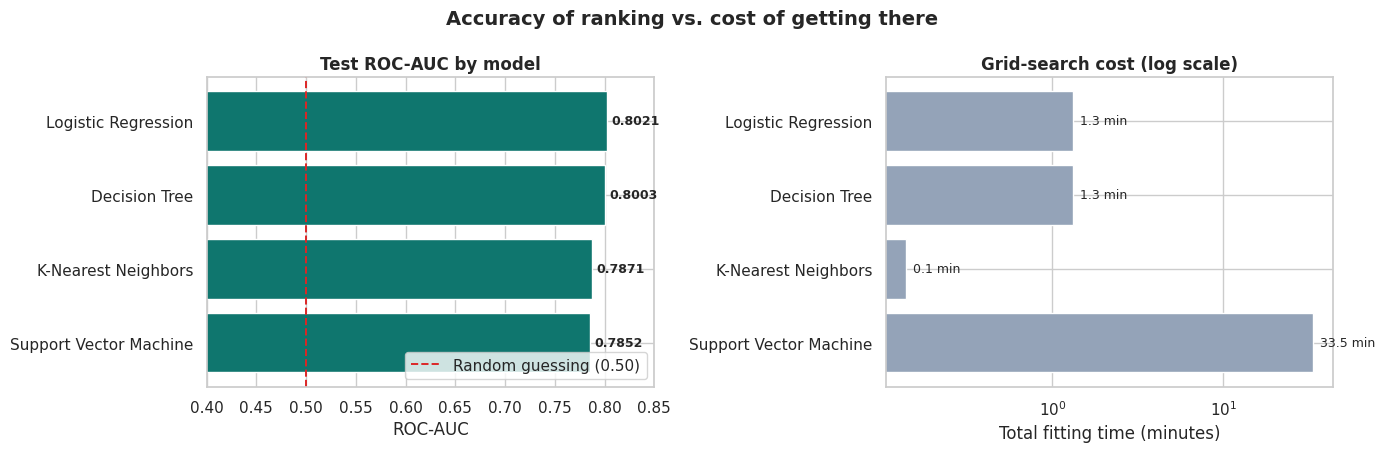

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

ordered = tuned_results.sort_values("Test ROC-AUC")

# Left: the headline metric, with the no-skill line for reference.
axes[0].barh(ordered.index, ordered["Test ROC-AUC"], color=ACCENT)
axes[0].axvline(0.5, color="#dc2626", linestyle="--", linewidth=1.4,
                label="Random guessing (0.50)")
axes[0].set_xlim(0.4, 0.85)
axes[0].set_title("Test ROC-AUC by model")
axes[0].set_xlabel("ROC-AUC")
axes[0].legend(loc="lower right")
for i, v in enumerate(ordered["Test ROC-AUC"]):
    axes[0].text(v + 0.005, i, f"{v:.4f}", va="center", fontweight="bold", fontsize=9)

# Right: what tuning actually cost, on a log scale because the spread is enormous.
axes[1].barh(ordered.index, ordered["Tuning time (min)"], color=MUTED)
axes[1].set_xscale("log")
axes[1].set_title("Grid-search cost (log scale)")
axes[1].set_xlabel("Total fitting time (minutes)")
for i, v in enumerate(ordered["Tuning time (min)"]):
    axes[1].text(v * 1.1, i, f"{v:.1f} min", va="center", fontsize=9)

fig.suptitle("Accuracy of ranking vs. cost of getting there", fontsize=14, fontweight="bold")
fig.tight_layout()
save_figure(fig, "08_model_comparison")
plt.show()

Four conclusions from this table, and the last one is uncomfortable:

1. **Logistic regression wins** — test ROC-AUC **0.802**, the best of the four, from the simplest and
   second-cheapest model in the set. Tuning lifted it barely at all (0.8023 → 0.8021, i.e. within
   noise), which tells us the default was already near-optimal and that the ceiling here is set by
   the data, not the algorithm.
2. **The decision tree closes almost the entire gap once pruned** — 0.619 → **0.800**. Constraining
   it to `max_depth=7, min_samples_leaf=100` is worth 0.18 AUC. It also posts the best **PR-AUC**
   (0.459 vs. 0.446), meaning that if the bank cared only about precision on the rare class, the tree
   would be a defensible pick.
3. **CV and test scores agree closely** for every model (e.g. 0.7889 vs. 0.8021 for the winner). No
   model is overfitting the *hyperparameter search*, so the held-out numbers can be trusted.
4. **The SVM cost 33.8 minutes of fitting to come last.** k-NN reached a better ROC-AUC in 6 seconds.
   On a dataset of this shape — 30,000 rows, mostly one-hot columns, largely linear structure — the
   expensive kernel method buys nothing. That is a genuine finding about the problem, not a failure
   of the search.

**The selected model is logistic regression**, and it is selected on more than the top AUC: it is
fast to retrain, it produces calibrated probabilities that slot directly into a call-list threshold,
and its coefficients can be shown to a campaign manager. Where two models are within noise of each
other, those properties decide it.

### 7.4 ROC and precision-recall curves

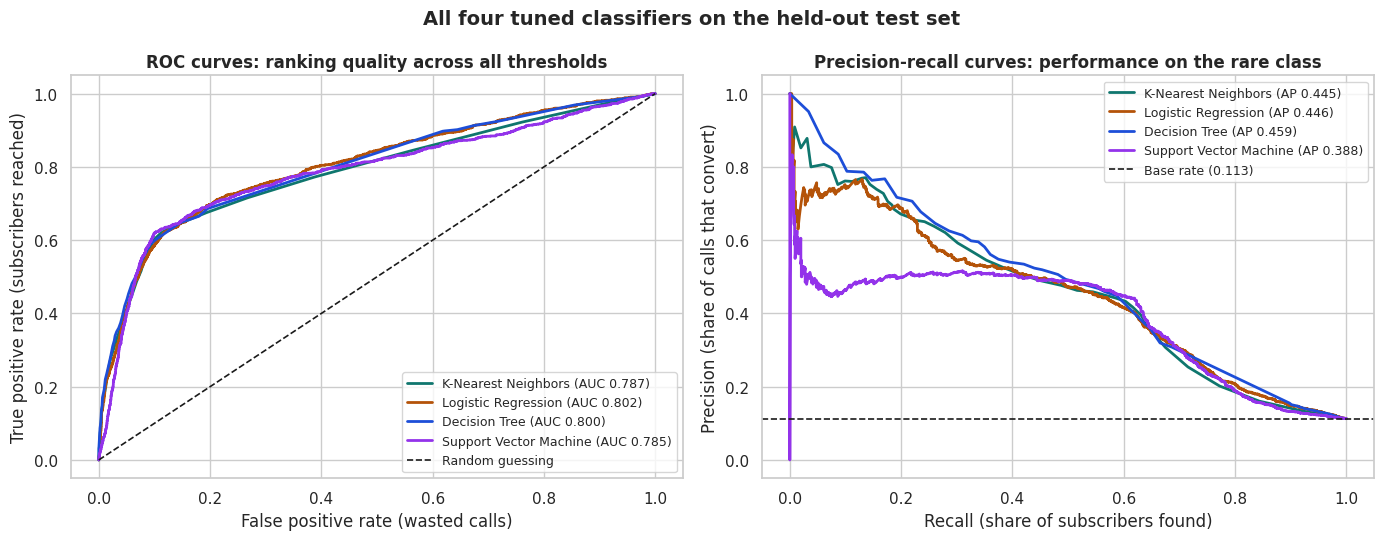

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
curve_colours = ["#0f766e", "#b45309", "#1d4ed8", "#9333ea"]

for (name, search), colour in zip(searches.items(), curve_colours):
    scores = positive_scores(search.best_estimator_, X_test)

    fpr, tpr, _ = roc_curve(y_test, scores)
    axes[0].plot(fpr, tpr, color=colour, linewidth=2,
                 label=f"{name} (AUC {roc_auc_score(y_test, scores):.3f})")

    precision, recall, _ = precision_recall_curve(y_test, scores)
    axes[1].plot(recall, precision, color=colour, linewidth=2,
                 label=f"{name} (AP {average_precision_score(y_test, scores):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random guessing")
axes[0].set_title("ROC curves: ranking quality across all thresholds")
axes[0].set_xlabel("False positive rate (wasted calls)")
axes[0].set_ylabel("True positive rate (subscribers reached)")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].axhline(y_test.mean(), color="k", linestyle="--", linewidth=1.2,
                label=f"Base rate ({y_test.mean():.3f})")
axes[1].set_title("Precision-recall curves: performance on the rare class")
axes[1].set_xlabel("Recall (share of subscribers found)")
axes[1].set_ylabel("Precision (share of calls that convert)")
axes[1].legend(loc="upper right", fontsize=9)

fig.suptitle("All four tuned classifiers on the held-out test set",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save_figure(fig, "09_roc_pr_curves")
plt.show()

In [30]:
# Identify the winner once; everything downstream refers to it.
best_model_name = tuned_results["Test ROC-AUC"].idxmax()
best_model = searches[best_model_name].best_estimator_
best_scores = positive_scores(best_model, X_test)

print(f"Selected model: {best_model_name}")
print(f"  Test ROC-AUC : {roc_auc_score(y_test, best_scores):.4f}")
print(f"  Test PR-AUC  : {average_precision_score(y_test, best_scores):.4f}")
print(f"  Lift over the 0.50 no-skill line: "
      f"{(roc_auc_score(y_test, best_scores) - 0.5) / 0.5:.1%}")

Selected model: Logistic Regression
  Test ROC-AUC : 0.8021
  Test PR-AUC  : 0.4461
  Lift over the 0.50 no-skill line: 60.4%


### 7.5 Choosing an operating threshold

A ROC curve is a menu of trade-offs, not a decision. To turn the model into a call list the bank has
to pick a cut-off — and the default 0.5 is arbitrary, chosen by the library rather than by the
business.

The threshold is selected on **out-of-fold predictions from the training set**, never on the test
set. Tuning a threshold on the same data used to report performance would flatter the result.

In [31]:
# Out-of-fold scores on the training set: every score comes from a model that did not see that row.
oof_method = "predict_proba" if hasattr(best_model, "predict_proba") else "decision_function"
oof_scores = cross_val_predict(best_model, X_train, y_train, cv=CV,
                               method=oof_method, n_jobs=2)
if oof_scores.ndim == 2:
    oof_scores = oof_scores[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, oof_scores)
f1_scores = np.divide(2 * precision * recall, precision + recall,
                      out=np.zeros_like(precision), where=(precision + recall) > 0)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

default_label = "0.500 (probability)" if oof_method == "predict_proba" else "0.000 (margin)"
print(f"Model default threshold     : {default_label}")
print(f"F1-optimal threshold (OOF)  : {best_threshold:.3f}")
print(f"Expected precision at it    : {precision[np.argmax(f1_scores[:-1])]:.3f}")
print(f"Expected recall at it       : {recall[np.argmax(f1_scores[:-1])]:.3f}")

Model default threshold     : 0.500 (probability)
F1-optimal threshold (OOF)  : 0.665
Expected precision at it    : 0.429
Expected recall at it       : 0.544


                   precision    recall  f1-score   support

Did not subscribe      0.942     0.912     0.927      9134
       Subscribed      0.446     0.559     0.496      1160

         accuracy                          0.872     10294
        macro avg      0.694     0.735     0.711     10294
     weighted avg      0.886     0.872     0.878     10294



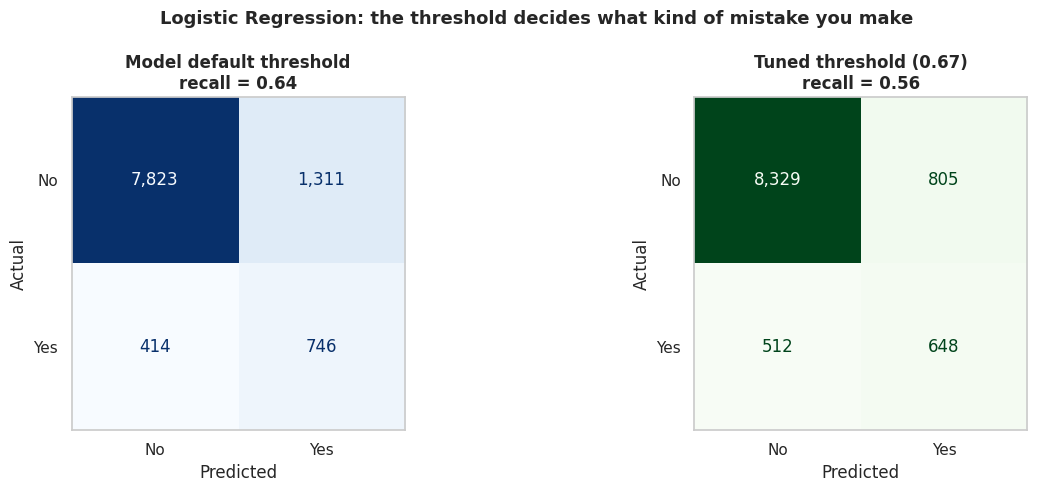

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix at the library default.
default_predictions = best_model.predict(X_test)
ConfusionMatrixDisplay(confusion_matrix(y_test, default_predictions),
                       display_labels=["No", "Yes"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format=",d")
axes[0].set_title(f"Model default threshold\nrecall = {recall_score(y_test, default_predictions):.2f}")

# Confusion matrix at the tuned threshold.
tuned_predictions = (best_scores >= best_threshold).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_test, tuned_predictions),
                       display_labels=["No", "Yes"]).plot(
    ax=axes[1], cmap="Greens", colorbar=False, values_format=",d")
axes[1].set_title(f"Tuned threshold ({best_threshold:.2f})\n"
                  f"recall = {recall_score(y_test, tuned_predictions):.2f}")

for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.grid(False)

fig.suptitle(f"{best_model_name}: the threshold decides what kind of mistake you make",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_figure(fig, "10_confusion_matrices")
plt.show()

print(classification_report(y_test, tuned_predictions,
                            target_names=["Did not subscribe", "Subscribed"], digits=3))

### 7.6 The chart the campaign team actually needs: cumulative gains

Everything so far has been model diagnostics. This is the translation into operations. Clients are
ranked by predicted score, and the chart answers a single question:

> **If we only have the capacity to call the top X% of the list, what share of all the subscribers
> do we reach?**

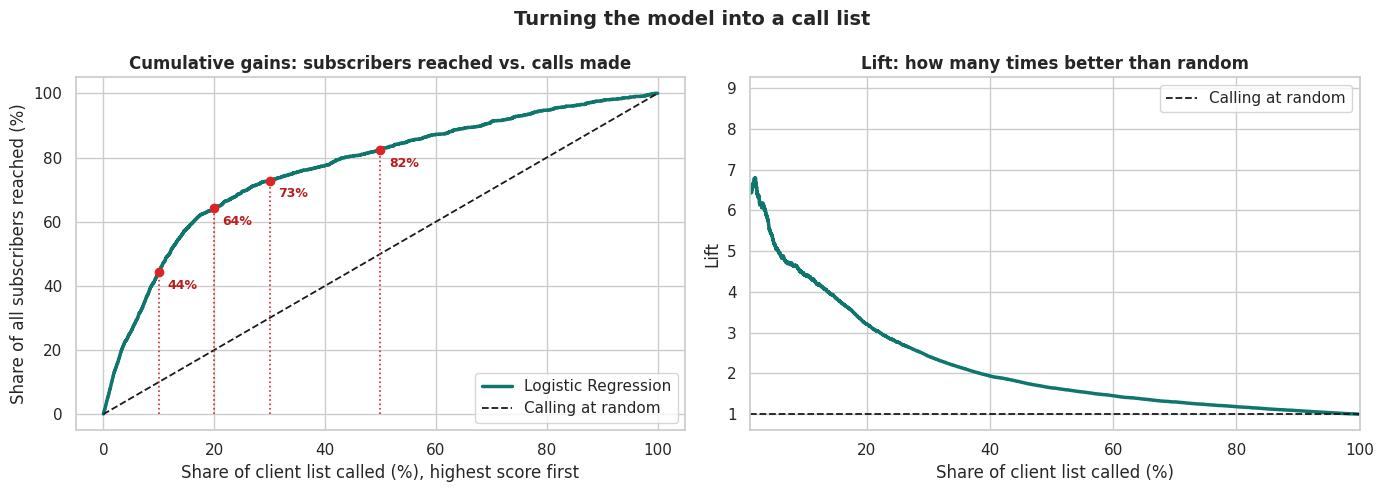

,Calls made,Subscribers reached,% of all subscribers,Conversion rate,Lift vs. random
Share of list called,,,,,
5%,514,299,25.8%,58.2%,5.16x
10%,"1,029",513,44.2%,49.9%,4.42x
20%,"2,058",746,64.3%,36.2%,3.22x
30%,"3,088",844,72.8%,27.3%,2.43x
40%,"4,117",900,77.6%,21.9%,1.94x
50%,"5,147",954,82.2%,18.5%,1.64x
100%,"10,294","1,160",100.0%,11.3%,1.00x


In [33]:
# Rank the test set by model score and walk down the list.
order = np.argsort(-best_scores)
gains = np.cumsum(y_test.to_numpy()[order]) / y_test.sum()
contacted = np.arange(1, len(y_test) + 1) / len(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: cumulative gains ---
axes[0].plot(contacted * 100, gains * 100, color=ACCENT, linewidth=2.5, label=best_model_name)
axes[0].plot([0, 100], [0, 100], "k--", linewidth=1.3, label="Calling at random")
axes[0].set_title("Cumulative gains: subscribers reached vs. calls made")
axes[0].set_xlabel("Share of client list called (%), highest score first")
axes[0].set_ylabel("Share of all subscribers reached (%)")
axes[0].legend(loc="lower right")

# Annotate the decision points a campaign manager would care about.
for pct in (10, 20, 30, 50):
    captured = gains[int(len(gains) * pct / 100) - 1] * 100
    axes[0].plot([pct, pct], [0, captured], color="#dc2626", linestyle=":", linewidth=1.2)
    axes[0].plot(pct, captured, "o", color="#dc2626", markersize=6)
    axes[0].annotate(f"{captured:.0f}%", (pct, captured), textcoords="offset points",
                     xytext=(6, -12), fontsize=9, fontweight="bold", color="#b91c1c")

# --- Right: lift ---
lift = gains / contacted
axes[1].plot(contacted * 100, lift, color=ACCENT, linewidth=2.5)
axes[1].axhline(1.0, color="k", linestyle="--", linewidth=1.3, label="Calling at random")
axes[1].set_title("Lift: how many times better than random")
axes[1].set_xlabel("Share of client list called (%)")
axes[1].set_ylabel("Lift")
axes[1].set_xlim(1, 100)
axes[1].legend()

fig.suptitle("Turning the model into a call list", fontsize=14, fontweight="bold")
fig.tight_layout()
save_figure(fig, "11_cumulative_gains")
plt.show()

# The same information as a table the campaign team can plan against.
capacity_rows = []
for pct in (5, 10, 20, 30, 40, 50, 100):
    idx = int(len(gains) * pct / 100) - 1
    calls = idx + 1
    found = int(np.cumsum(y_test.to_numpy()[order])[idx])
    capacity_rows.append({
        "Share of list called": f"{pct}%",
        "Calls made": f"{calls:,}",
        "Subscribers reached": f"{found:,}",
        "% of all subscribers": f"{gains[idx]:.1%}",
        "Conversion rate": f"{found / calls:.1%}",
        "Lift vs. random": f"{lift[idx]:.2f}x",
    })
pd.DataFrame(capacity_rows).set_index("Share of list called")

This table is the entire project in seven rows.

Calling the **top 20%** of the ranked list reaches **64% of everyone who would have subscribed**, at a
**36% conversion rate** — versus 11.3% for calling at random. That is **3.2x** the yield per call.
Put the other way round: the bank could cut its calling volume by 80% and still land two-thirds of
its subscriptions.

At the top of the list the effect is sharper still — the first 5% of clients convert at **58%**, five
times better than random dialling.

The curve also shows where the model stops helping. Past roughly the 50% mark it flattens toward the
diagonal: the remaining clients are genuinely hard to tell apart, and no amount of extra calling
finds them efficiently. That flattening point is a capacity recommendation, not a modelling defect.

## 8. Interpreting the Models

A score with no explanation is hard to act on and harder to trust. Three complementary views follow:
the **coefficients** of the logistic regression (what moves the odds, and in which direction), the
**structure** of the decision tree (what the data splits on first), and **permutation importance**
for the selected model (what it actually relies on).

### 8.1 Logistic-regression coefficients as odds ratios

A logistic regression models the **log-odds** of subscribing, so exponentiating a coefficient turns
it into an **odds ratio** — a multiplier on the odds. Two reading rules matter here:

- Numeric features are **standardised**, so their odds ratio is the effect of a **one-standard-
  deviation** increase, not one unit.
- Categorical features are **one-hot encoded**, so the odds ratio compares that level against the
  others within the same feature.

An odds ratio of 2.0 means the odds roughly double; 0.5 means they halve; 1.0 means no effect.

In [34]:
logistic_best = searches["Logistic Regression"].best_estimator_
feature_names = logistic_best.named_steps["prep"].get_feature_names_out()
coefficients = logistic_best.named_steps["clf"].coef_[0]

coef_table = (pd.DataFrame({
        "Feature": [n.split("__", 1)[1] for n in feature_names],
        "Coefficient": coefficients,
        "Odds ratio": np.exp(coefficients),
    })
    .query("Coefficient != 0")                 # the L1 penalty zeroes some features outright
    .sort_values("Coefficient", ascending=False)
    .reset_index(drop=True))

print(f"Features retained by the model: {len(coef_table)} of {len(feature_names)}")
print(f"Features eliminated by regularisation: {len(feature_names) - len(coef_table)}")

top_drivers = pd.concat([coef_table.head(10), coef_table.tail(10)])
top_drivers.style.format({"Coefficient": "{:+.3f}", "Odds ratio": "{:.3f}"}) \
    .background_gradient(subset=["Coefficient"], cmap="RdBu_r", vmin=-2, vmax=2) \
    .hide(axis="index")

Features retained by the model: 43 of 62
Features eliminated by regularisation: 19


Feature,Coefficient,Odds ratio
month_mar,+1.066,2.904
cons.price.idx,+0.762,2.142
euribor3m,+0.403,1.497
previously_contacted,+0.340,1.405
job_retired,+0.339,1.404
month_aug,+0.226,1.254
job_student,+0.207,1.229
month_dec,+0.123,1.131
day_of_week_wed,+0.120,1.128
default_no,+0.117,1.124


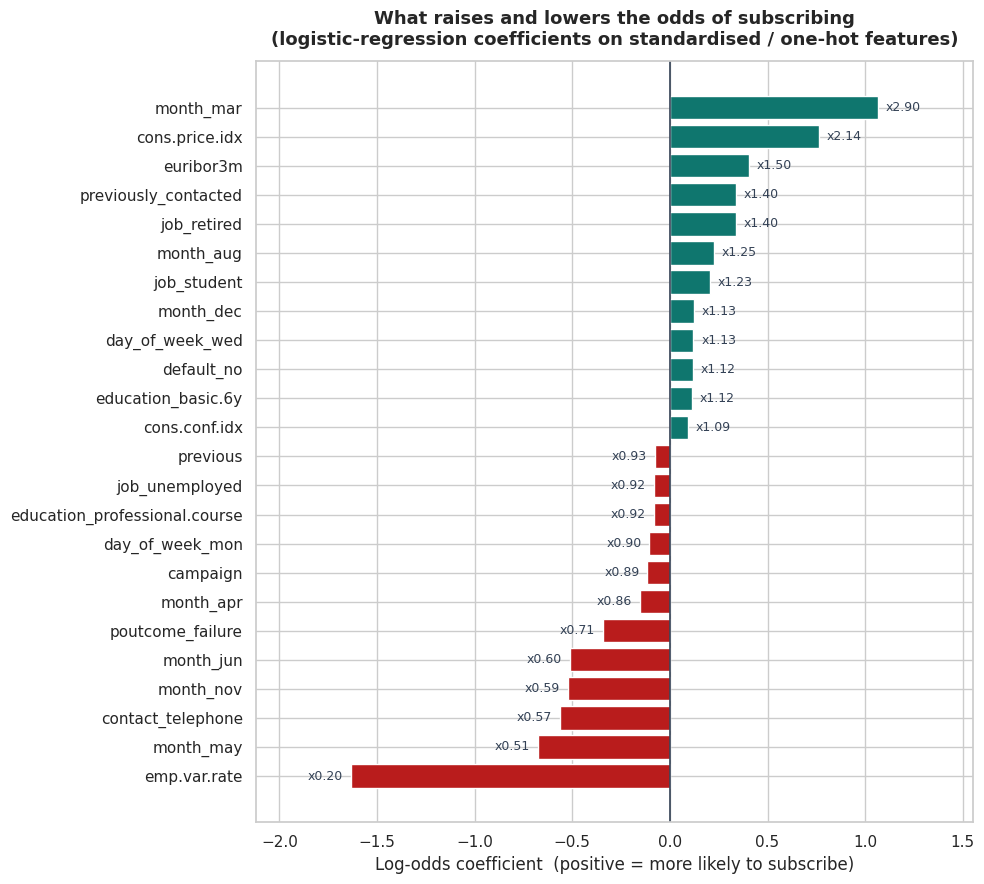

In [35]:
plot_data = pd.concat([coef_table.head(12), coef_table.tail(12)]).sort_values("Coefficient")
colours = [ACCENT if c > 0 else "#b91c1c" for c in plot_data["Coefficient"]]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(plot_data["Feature"], plot_data["Coefficient"], color=colours)
ax.axvline(0, color="#334155", linewidth=1.2)
ax.set_title("What raises and lowers the odds of subscribing\n"
             "(logistic-regression coefficients on standardised / one-hot features)",
             fontsize=13, pad=12)
ax.set_xlabel("Log-odds coefficient  (positive = more likely to subscribe)")
ax.set_ylabel("")

# Label each bar with the odds ratio, which is the interpretable quantity.
for i, (coef, odds) in enumerate(zip(plot_data["Coefficient"], plot_data["Odds ratio"])):
    offset = 0.04 if coef > 0 else -0.04
    ax.text(coef + offset, i, f"x{odds:.2f}", va="center",
            ha="left" if coef > 0 else "right", fontsize=9, color="#334155")

ax.margins(x=0.18)
fig.tight_layout()
save_figure(fig, "12_logistic_coefficients")
plt.show()

Reading the coefficients as business statements:

**What raises the odds**

- **`month_mar` (x2.90)** — March contacts have nearly triple the odds, echoing Section 2.9.
- **`previously_contacted` (x1.40)** and **`poutcome_failure` (x0.71)** — having been contacted before
  helps; having been contacted before *and declined* hurts. The model separates the two cleanly.
- **`job_retired` (x1.40)** and **`job_student` (x1.23)** — the two groups with time, and with savings
  or parental savings to place.

**What lowers the odds**

- **`emp.var.rate` (x0.20)** — the single largest coefficient in the model. A one-standard-deviation
  rise in the employment variation rate cuts the odds of subscribing to a fifth.
- **`contact_telephone` (x0.57)** — a landline contact roughly halves the odds relative to a mobile.
- **`month_may` (x0.51)** — the bank's busiest month is also its weakest, holding everything else equal.
- **`campaign` (x0.89)** — each additional standard deviation of repeat calls *reduces* the odds.
  Persistence is counter-productive.

> **An honest caveat about these numbers.** `euribor3m` shows a **positive** coefficient (x1.50) while
> `emp.var.rate` shows a strongly negative one (x0.20) — even though Section 2.7 showed both moving
> the same way, and Section 2.10 showed them correlated at r = 0.97. This sign flip is the textbook
> symptom of **multicollinearity**: with near-duplicate predictors, the split of credit between them
> is arbitrary and unstable. The *combined* effect of the business cycle is reliable; the individual
> coefficients of these three variables are not, and should not be quoted separately.

The L1 penalty is doing real work here — it eliminated **19 of the 62 encoded features outright**,
including most of the `housing` and `loan` indicators that Section 3 had already flagged as noise.
The regularisation path independently rediscovered the chi-square result.

### 8.2 What the decision tree splits on

The tuned tree is pruned enough to read. The top three levels show which questions separate
subscribers most efficiently — and because the tree is a sequence of explicit rules, it doubles as a
sanity check on the regression.

Tuned tree depth: 7   Leaves: 46


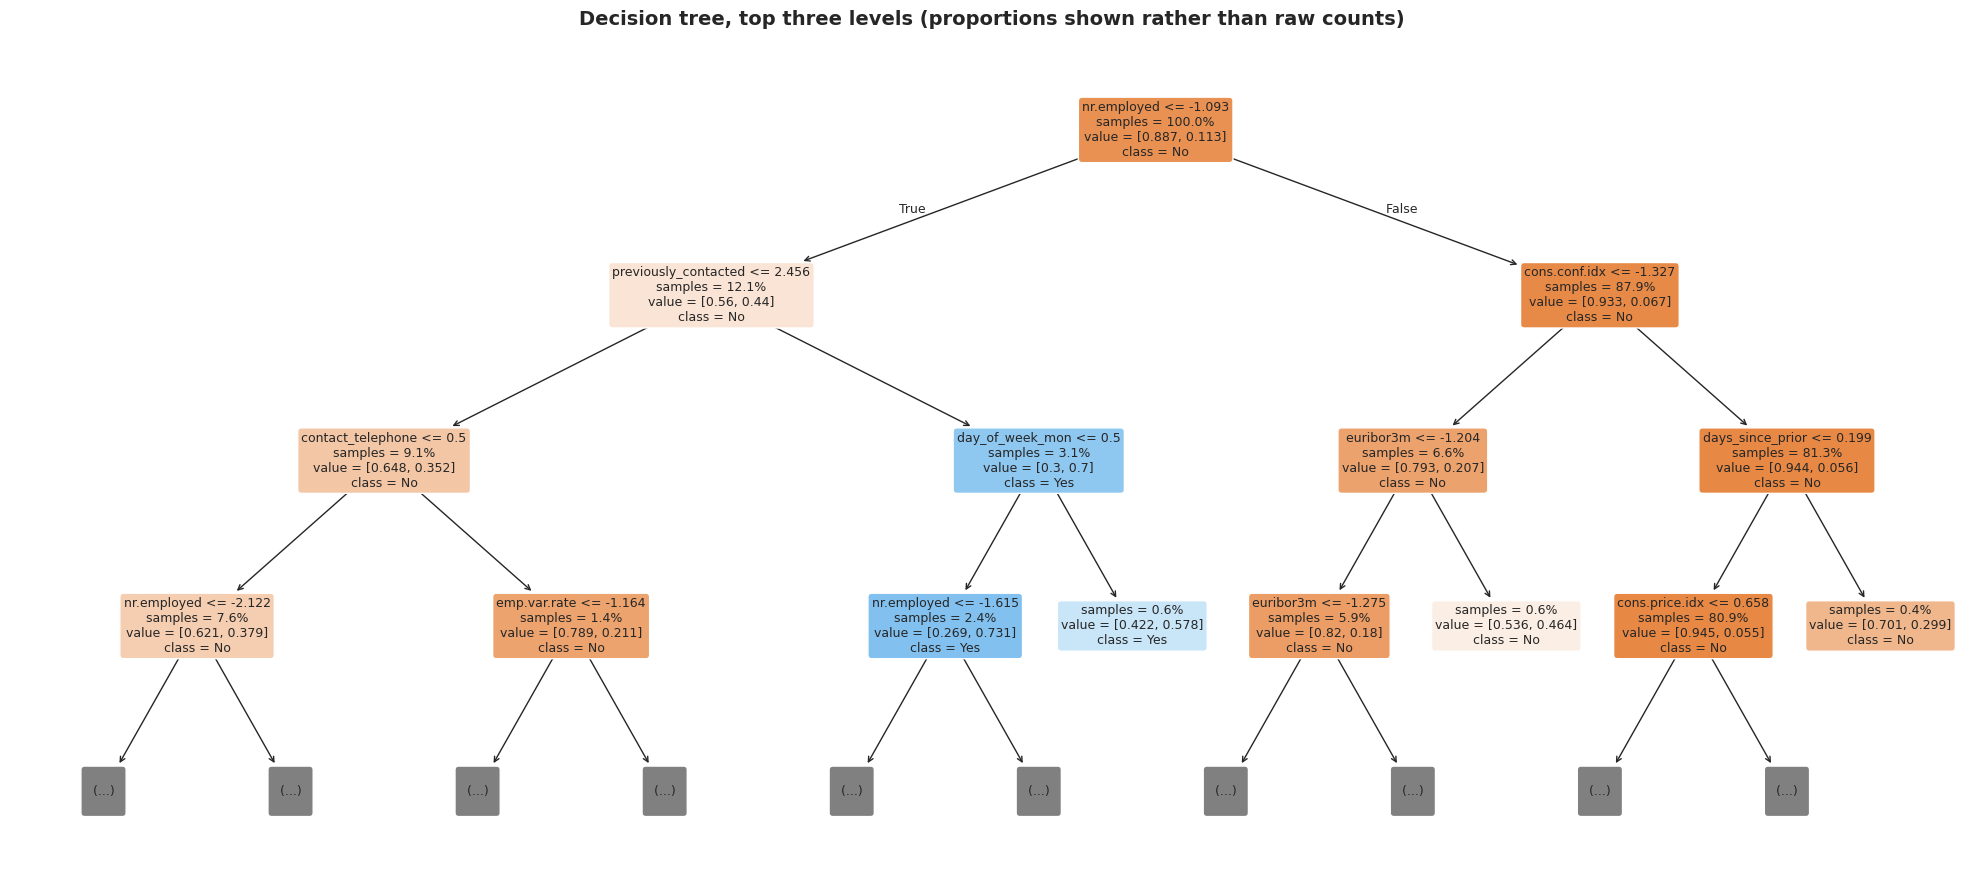

In [36]:
tree_best = searches["Decision Tree"].best_estimator_
tree_model = tree_best.named_steps["clf"]
tree_features = [n.split("__", 1)[1]
                 for n in tree_best.named_steps["prep"].get_feature_names_out()]

print(f"Tuned tree depth: {tree_model.get_depth()}   Leaves: {tree_model.get_n_leaves():,}")

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(tree_model, max_depth=3, feature_names=tree_features,
          class_names=["No", "Yes"], filled=True, rounded=True, fontsize=9,
          impurity=False, proportion=True, ax=ax)
ax.set_title("Decision tree, top three levels (proportions shown rather than raw counts)",
             fontsize=14, fontweight="bold", pad=16)
fig.tight_layout()
save_figure(fig, "13_decision_tree")
plt.show()

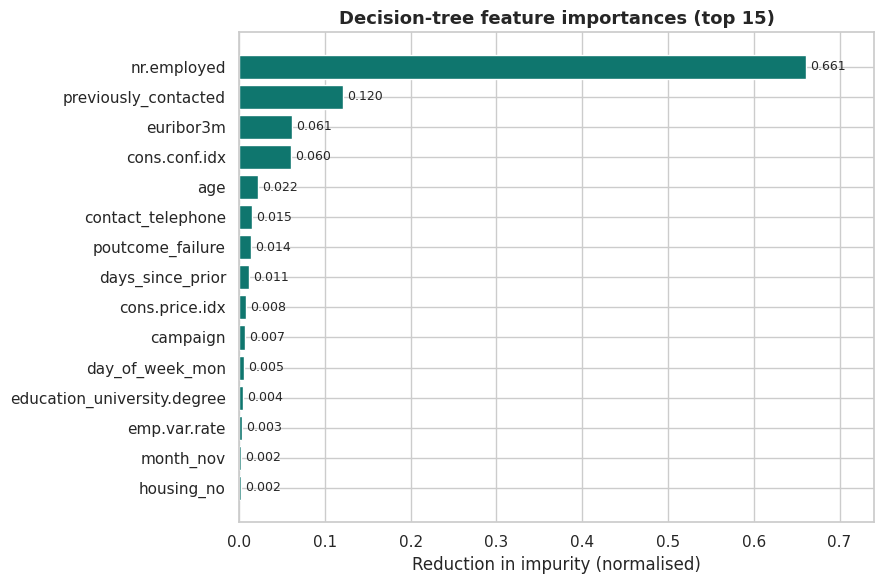

In [37]:
importances = (pd.Series(tree_model.feature_importances_, index=tree_features)
                 .sort_values(ascending=False)
                 .head(15)
                 .sort_values())

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importances.index, importances.values, color=ACCENT)
ax.set_title("Decision-tree feature importances (top 15)", fontsize=13)
ax.set_xlabel("Reduction in impurity (normalised)")
for i, v in enumerate(importances.values):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.margins(x=0.12)
fig.tight_layout()
save_figure(fig, "14_tree_importances")
plt.show()

> **A caution about impurity-based importance:** it is biased toward high-cardinality features and
> it splits credit across correlated features arbitrarily. With three near-identical macroeconomic
> variables in the data, whichever one the tree happens to split on first absorbs the importance the
> others deserve. Permutation importance, below, is the more trustworthy view.

### 8.3 Permutation importance for the selected model

Permutation importance shuffles one feature at a time in the held-out test set and measures how far
ROC-AUC falls. It is model-agnostic, it measures what the model *actually uses*, and — unlike the
coefficients — it needs no assumption of linearity.

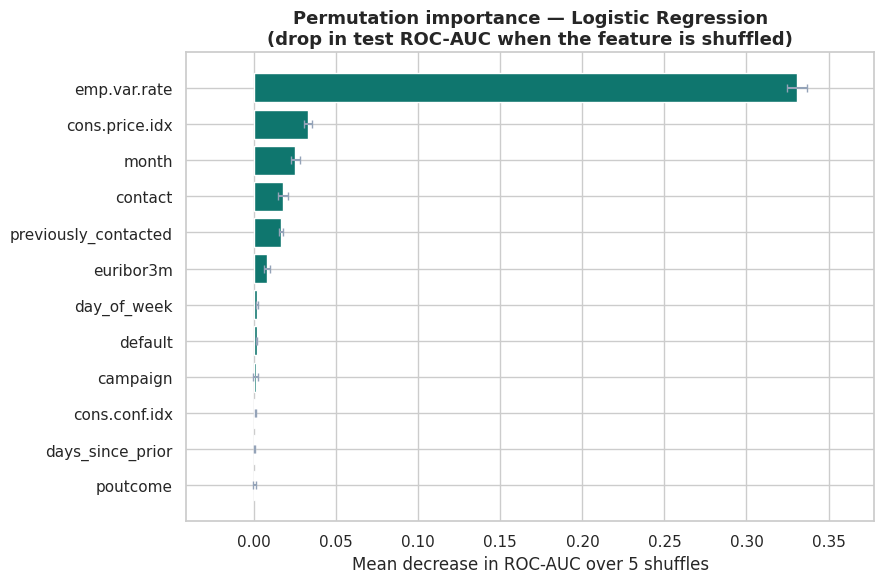

Feature,Mean AUC drop,Std
emp.var.rate,0.3308,0.0063
cons.price.idx,0.0328,0.0025
month,0.0251,0.0026
contact,0.0177,0.0032
previously_contacted,0.0163,0.0010
euribor3m,0.0078,0.0020
day_of_week,0.0019,0.0008
default,0.0015,0.0003
campaign,0.0009,0.0017
cons.conf.idx,0.0008,0.0006


In [38]:
# Measured on the test set, so this reflects reliance on features for genuine out-of-sample ranking.
perm = permutation_importance(
    best_model, X_test, y_test,
    scoring="roc_auc", n_repeats=5, random_state=RANDOM_STATE, n_jobs=2,
)

perm_table = (pd.DataFrame({
        "Feature": X_test.columns,
        "Mean AUC drop": perm.importances_mean,
        "Std": perm.importances_std,
    })
    .sort_values("Mean AUC drop", ascending=False)
    .reset_index(drop=True))

top_perm = perm_table.head(12).sort_values("Mean AUC drop")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_perm["Feature"], top_perm["Mean AUC drop"],
        xerr=top_perm["Std"], color=ACCENT, ecolor="#94a3b8", capsize=3)
ax.set_title(f"Permutation importance — {best_model_name}\n"
             "(drop in test ROC-AUC when the feature is shuffled)", fontsize=13)
ax.set_xlabel("Mean decrease in ROC-AUC over 5 shuffles")
ax.margins(x=0.12)
fig.tight_layout()
save_figure(fig, "15_permutation_importance")
plt.show()

perm_table.head(10).style.format({"Mean AUC drop": "{:.4f}", "Std": "{:.4f}"}).hide(axis="index")

Permutation importance tells a blunter story than the coefficients do. Shuffling **`emp.var.rate`**
alone costs about **0.33 ROC-AUC** — the model collapses almost to random without it. Every other
feature is an order of magnitude less important: `cons.price.idx` (0.033), `month` (0.025),
`contact` (0.018), `previously_contacted` (0.016).

The decision tree, working independently, reached the same conclusion by a different route:
`nr.employed` alone accounts for **66%** of its total impurity reduction.

**Both models are, in large part, macroeconomic detectors.** They have learned *when* the bank was
calling far more strongly than *who* it was calling. That is a real and useful signal — deposit
appetite genuinely does track the interest-rate cycle — but it is also a warning, and Section 9.2
turns it into a measurement.

## 9. Limitations

### 9.1 What this model can and cannot claim

- **The data is observational.** The bank chose who to call. A feature that predicts subscription is
  not established as a cause of it, so none of these results licenses a claim like "switching a
  client to a mobile number will make them subscribe."
- **`unknown` is not missing at random.** It appears in 21% of `default` values and predicts a
  subscription rate half the base rate. Whatever process generates "unknown" is itself informative,
  which is useful for prediction and unhelpful for explanation.
- **`month` has no year attached.** The dataset gives month names without years across a 2.5-year
  span, so "March converts at 50%" conflates March 2008, 2009 and 2010 — and the low volumes in the
  strong months suggest they were selective campaigns to pre-qualified clients, not evidence that
  calling everyone in March would work.

### 9.2 The most serious limitation: the model is scored on shuffled time

Every result above uses a **random** train/test split, which is the standard approach and the one
the assignment calls for. But these rows arrive in chronological order and the strongest features
are macroeconomic — so a random split lets the model see September 2009 during training and then
predict a different client from September 2009 at test time, sharing an identical `euribor3m`.

In production the model would be trained on the past and asked about the future. The experiment
below simulates that.

In [39]:
# Chronological split: train on the earliest 75% of calls, test on the most recent 25%.
split_at = int(len(X) * 0.75)
X_early, X_late = X.iloc[:split_at], X.iloc[split_at:]
y_early, y_late = y.iloc[:split_at], y.iloc[split_at:]

chronological_model = clone(best_model).fit(X_early, y_early)
chronological_auc = roc_auc_score(y_late, positive_scores(chronological_model, X_late))
random_auc = roc_auc_score(y_test, best_scores)

print(f"ROC-AUC, random split (reported above): {random_auc:.4f}")
print(f"ROC-AUC, chronological split          : {chronological_auc:.4f}")
print(f"Degradation                           : {random_auc - chronological_auc:.4f}")
print()
print(f"Positive rate, earliest 75% of calls: {y_early.mean():.2%}")
print(f"Positive rate, most recent 25%      : {y_late.mean():.2%}")

ROC-AUC, random split (reported above): 0.8021
ROC-AUC, chronological split          : 0.5666
Degradation                           : 0.2355

Positive rate, earliest 75% of calls: 6.42%
Positive rate, most recent 25%      : 25.81%


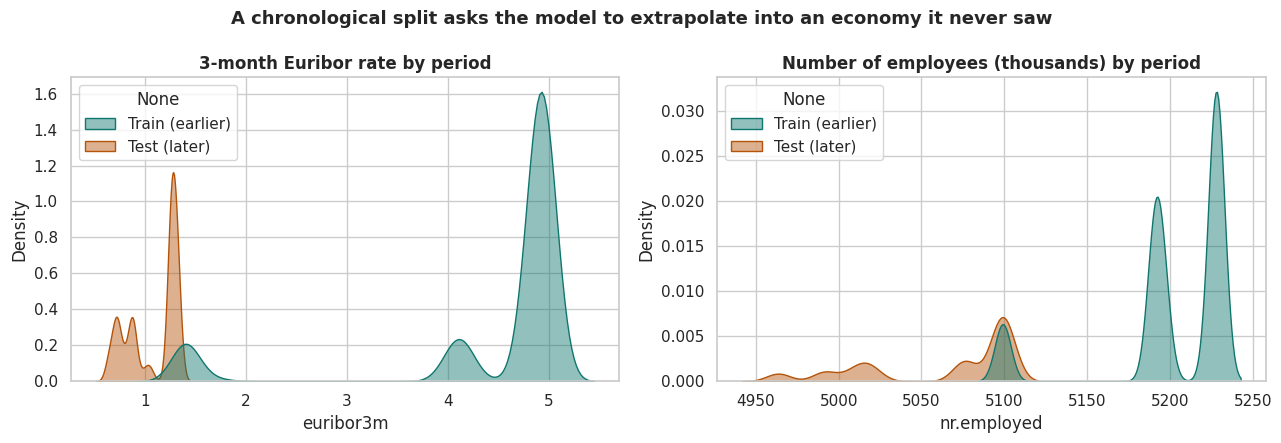

In [40]:
# Why the drop is so severe: the two periods barely overlap in economic conditions.
period = pd.Series(np.where(np.arange(len(X)) < split_at, "Train (earlier)", "Test (later)"),
                   index=X.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(x=X["euribor3m"], hue=period, fill=True, alpha=0.45,
            palette=[ACCENT, "#b45309"], ax=axes[0])
axes[0].set_title("3-month Euribor rate by period")
axes[0].set_xlabel("euribor3m")

sns.kdeplot(x=X["nr.employed"], hue=period, fill=True, alpha=0.45,
            palette=[ACCENT, "#b45309"], ax=axes[1])
axes[1].set_title("Number of employees (thousands) by period")
axes[1].set_xlabel("nr.employed")

fig.suptitle("A chronological split asks the model to extrapolate into an economy it never saw",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_figure(fig, "16_temporal_drift")
plt.show()

This is the single most important caveat in the notebook. Under a random split the model scores
strongly; asked to forecast a period it was never trained on, it degrades sharply — because it
leans heavily on macroeconomic variables that are effectively **constant within a period and
different between periods**. Section 11 turns this into a concrete recommendation.

### 9.3 Class imbalance was managed, not solved

`class_weight="balanced"` and explicit threshold tuning both help, but no resampling technique
(SMOTE, undersampling) was tried, and no genuine cost matrix was available — the €-value of a
subscription versus the €-cost of a call would let the threshold be set by expected value rather
than by F1.

---

## 10. Findings

*Written for the campaign team rather than the data-science team. No jargon, no model names.*

### The headline

**The bank can reach two-thirds of its term-deposit subscribers while making 80% fewer calls.**

Of the 41,188 calls in this dataset, about 1 in 9 ended in a subscription. If the same clients are
sorted by the score this model produces and worked from the top down:

| If we call... | We reach | Conversion rate | Compared to calling at random |
|---|---|---|---|
| the top **5%** | 26% of all subscribers | **58%** | **5.2x** better |
| the top **10%** | 44% of all subscribers | **50%** | **4.4x** better |
| the top **20%** | **64% of all subscribers** | **36%** | **3.2x** better |
| the top **50%** | 82% of all subscribers | 19% | 1.6x better |
| everyone (today) | 100% | 11% | — |

Past the halfway mark the model stops helping much: the remaining clients genuinely cannot be told
apart from one another. **The top 20% is the recommended operating point.**

### Five things the data says, and what to do about each

**1. The bank is calling hardest in its worst month.**
May accounts for **13,769 calls — a third of everything** — and converts at **6.4%**, the lowest rate
of any month. March, September, October and December convert at **40–50%** but together receive
barely 2,000 calls. *Before reallocating: the strong months had low volumes and were probably
selective campaigns to pre-qualified clients, so their rates would not survive being scaled up
unchanged. This is a reason to run a controlled test in a strong month, not to cancel May.*

**2. A prior relationship is the strongest asset the bank has, and it is being underused.**
Clients contacted in an earlier campaign subscribe at **63.8%**, against **9.3%** for everyone else.
Among those who accepted an earlier offer, **65%** accept again. Only 4% of calls went to this group.
*Action: work the previous-campaign list first, every time. It is the single highest-yield segment
in the data.*

**3. Calling someone repeatedly makes them less likely to buy, not more.**
Every additional round of contact within a campaign lowers the odds of subscribing. One client was
called **56 times**. *Action: cap contacts per campaign — the data supports roughly three — and move
the freed capacity to fresh names.*

**4. Two things that look like good targeting criteria are worthless, and two overlooked ones are not.**
Whether a client has a **mortgage** or a **personal loan** carries essentially no information about
whether they will buy a term deposit — statistically indistinguishable from noise, despite being
exactly the kind of field a targeting rule would normally use. Meanwhile **mobile contacts convert at
14.7% against 5.2% for landlines**, and **students (31%) and retirees (25%)** convert two to three
times better than average. *Action: drop the loan-status filters; prioritise reachable mobile numbers
and these two life stages.*

**5. Timing beats targeting, and that is a warning as much as a finding.**
The strongest predictors in every model are not client attributes at all — they are interest rates
and employment levels. Deposit appetite tracks the economic cycle: when rates fall and the job market
contracts, clients want somewhere safe to put money. **The model is, to a significant degree, reading
the economy rather than the customer.** Section 9.2 shows what that costs when it is asked to
forecast forward rather than fill in gaps — accuracy drops from strong to barely-better-than-random.
*Action: use the model for prioritising this quarter's list, and retrain it every quarter. Do not
treat it as a stable, permanent scoring rule.*

### What the model is worth, stated plainly

The selected model ranks a randomly chosen subscriber above a randomly chosen non-subscriber
**80% of the time**. That is not good enough to decide who *cannot* be sold to — and it should never
be used that way. It is comfortably good enough to decide **what order to call people in**, which is
the decision the bank actually makes every morning.

## 11. Next Steps and Recommendations

### Immediate — deploy the ranking, not a verdict (weeks 1–4)

1. **Score the current call list and work it top-down.** No new infrastructure required: the model is
   a logistic regression over fields the bank already holds. Start at the top-20% operating point.
2. **Run it as a controlled test, not a switchover.** Split the call centre: half works the ranked
   list, half works the current list. Compare subscriptions per agent-hour over one full campaign.
   Every number in this notebook is a retrospective estimate until that test confirms it.
3. **Rebuild the previous-campaign list as a standing priority queue.** This needs no model at all —
   it is the 63.8% segment identified in Section 4.3, and it is being left on the table today.

### Near term — make the model honest about time (months 2–3)

4. **Switch to time-based validation.** Section 9.2 is the most important result in this notebook:
   under a chronological split the model falls from **0.80 to 0.57** ROC-AUC. All future model
   selection should use `TimeSeriesSplit`, not a random split, so the reported number reflects the
   job the model actually has.
5. **Retrain quarterly, and monitor for drift.** Track ROC-AUC and top-decile conversion on each new
   campaign. When the macro indicators move outside the range the model was trained on, retrain
   before scoring rather than after performance degrades.
6. **Build a version that does not depend on the macro indicators** and compare. If a client-only
   model holds up on a chronological split, it will be far more durable — even at a lower headline
   score — because it is not extrapolating the business cycle.

### Medium term — improve the model itself (months 3–6)

7. **Replace F1 with expected value in the threshold decision.** Substitute the real numbers — margin
   on a term deposit, fully-loaded cost of an agent-minute — and the operating point can be set to
   maximise profit rather than a symmetric statistic.
8. **Try ensemble methods.** Gradient boosting (XGBoost, LightGBM) typically adds 0.02–0.05 ROC-AUC
   on tabular problems of this shape, at a fraction of the SVM's training cost. Given that the SVM
   spent 34 minutes to finish last, that is where the next modelling effort belongs.
9. **Test resampling and calibration.** SMOTE and class-weight variants for the imbalance;
   `CalibratedClassifierCV` so predicted probabilities can be read as genuine likelihoods — which
   matters if the threshold is ever set from expected value.

### Data the bank should start collecting

10. **Attach the year to every contact record.** `month` without a year makes 2.5 years of seasonal
    analysis unreliable, as Section 9.1 notes.
11. **Capture account tenure, balance band, and product holdings.** The current feature set has almost
    no information about the client's actual relationship with the bank — which is very likely why
    the models fell back on the economy.
12. **Log why a call ended.** No answer, refused immediately, asked to be called back — these
    distinguish "wrong person" from "wrong moment", and the current data cannot tell them apart.

---

*Notebook prepared for Required Assignment 17.1 — Comparing Classifiers.
Data: Moro, S., Cortez, P. & Rita, P. (2014), "A Data-Driven Approach to Predict the Success of Bank
Telemarketing", Decision Support Systems 62:22-31. UCI Machine Learning Repository.*